# Engenharia de Características para a Aprendizagem Computacional
## Trabalho Prático 1
Trabalho realizado por:
- 
- 
- 

### Dataset
O Dataset utilizado é o FORTH-TRACE benchmark. O mesmo contém dados recolhidos de 5 sensores, incluindo sensores de aceleração, velocidade angular e variação do campo magnético, quer da parte superior, quer da parte inferior, do corpo.

### Bibliotecas Utilizadas

In [4]:
import numpy as np
import csv
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib.cm as cm

### Exercício 2
#### 1. Carregamento dos dados
Os dados foram carregados a partir dos ficheiros CSV disponibilizados no dataset. À medida que os dados foram sendo adicionados a um array auxiliar, foi também adicionada uma coluna com o ID do participante, de forma a manter essa informação para os passos seguintes.

In [5]:
def load_data():
    dataset_root='../FORTH_TRACE_DATASET'
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    # add participant ID
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)

    return data


#fiz isto só p ver como estavam os dados
data= load_data()
print(data[:5])  


[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]


### Exercício 3
Análise e tratamento de outliers: o objetivo será identificar e tratar outliers usando diferentes abordagens univariável e multivariável. Para o efeito iremos utilizar os módulos dos vectores aceleração, giroscópio e magnetómetro. Seja
$$ \vec{t} = (tx, ty, tz) $$
o vector aceleração, giroscópio e magnetómetro. O respetivo módulo é determinado recorrendo:
$$ ||\vec{t}|| = \sqrt{tx^2 + ty^2 + tz^2} $$

### Exercício 3.1
Elabore uma rotina que apresente simultaneamente o boxplot de cada atividade (coluna 12 – eixo horizontal) relativo a todos os sujeitos e a uma das seguintes variáveis transformadas: módulos dos vectores de aceleração, giroscópio e magnetómetro. Sugere-se o uso da biblioteca matplotlib, por exemplo, a classe matplotlib.pyplot.boxplot.

In [5]:
def module_boxplots(data, sensor):
    if sensor == 1:
        c = (2,3,4)
        label = 'Aceleration'
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 1, 2 ou 3")

    mod = np.sqrt((data[:, c]**2).sum(axis=1))

    device = data[:, 1].astype(int)
    activities = data[:, 12].astype(int)

    unique_activities = np.unique(activities)
    unique_devices = np.unique(device)

    #para cada atividade
    for act in unique_activities:
        plt.figure(figsize=(10, 5))
        boxplot_data = []
        labels = []

        # boxplot para cada dispositivo
        for dev in unique_devices:
            mask = (activities == act) & (device == dev)
            mod_from_act = mod[mask]
            if len(mod_from_act) > 0:
                boxplot_data.append(mod_from_act)
                labels.append(f'Device {dev}')

        plt.boxplot(boxplot_data, labels=labels, showfliers=False)
        plt.title(f'{label} - Activity {act}')
        plt.xlabel('Device')
        plt.ylabel(f'{label} Module')
        plt.tight_layout()
        plt.show()


/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


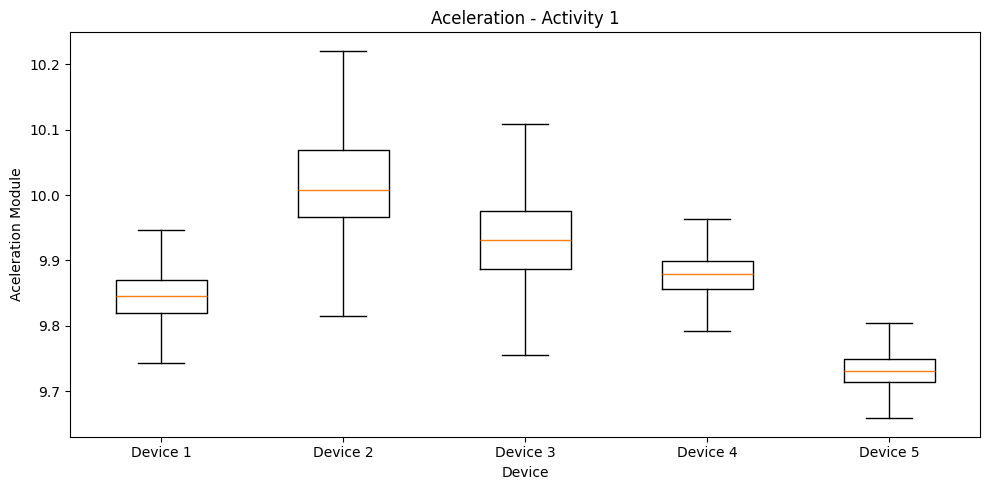

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


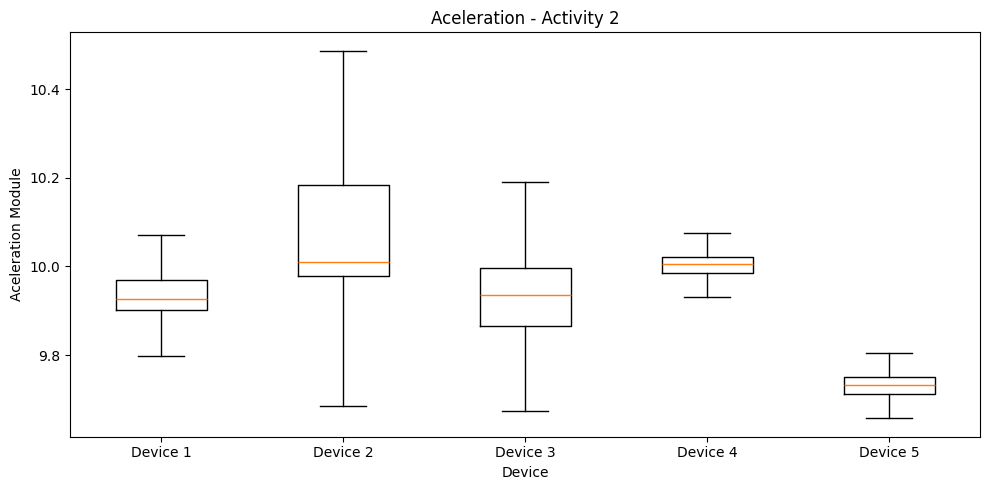

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


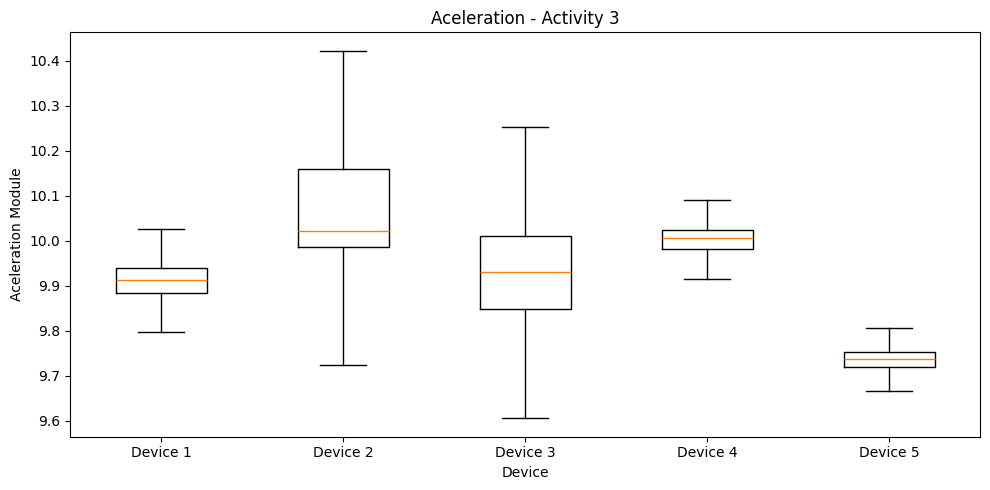

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


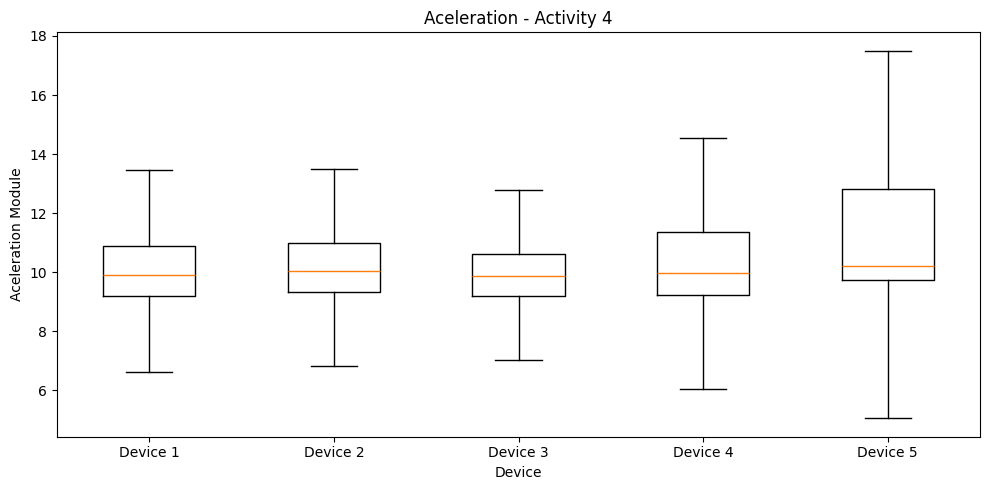

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


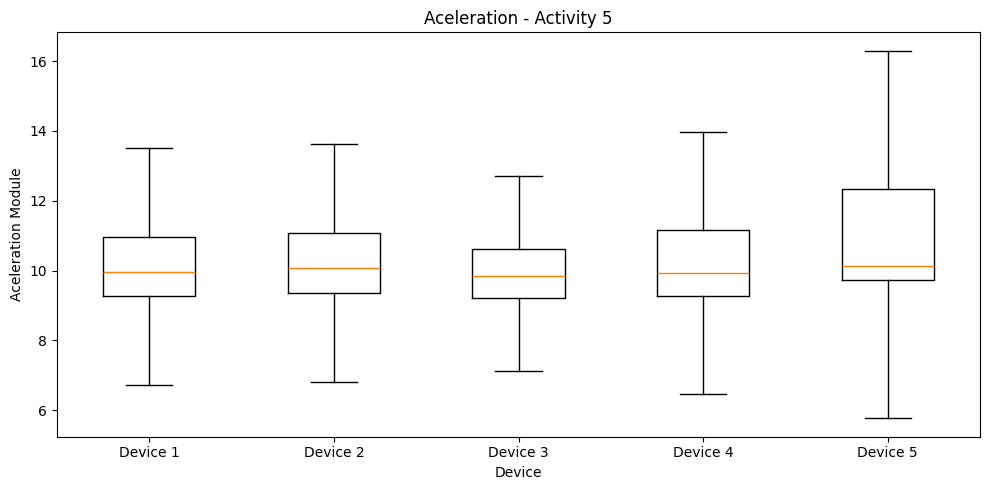

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


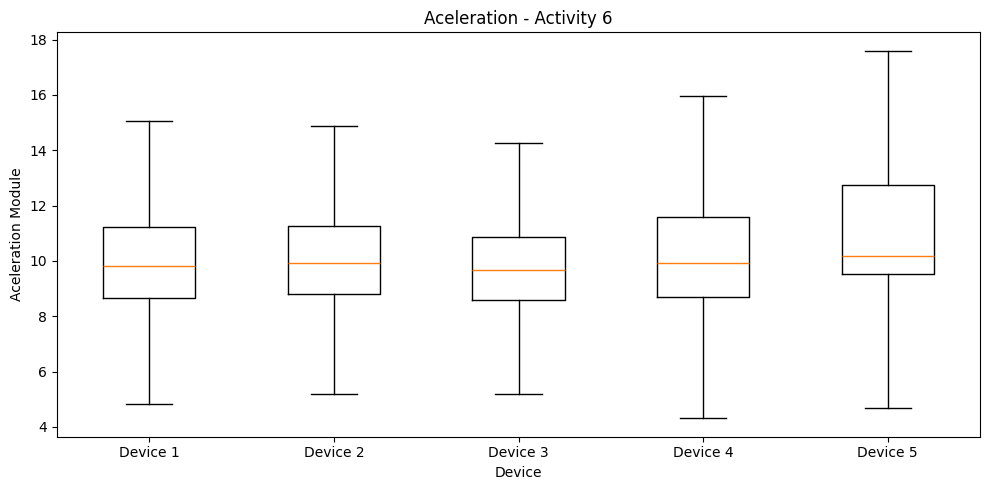

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


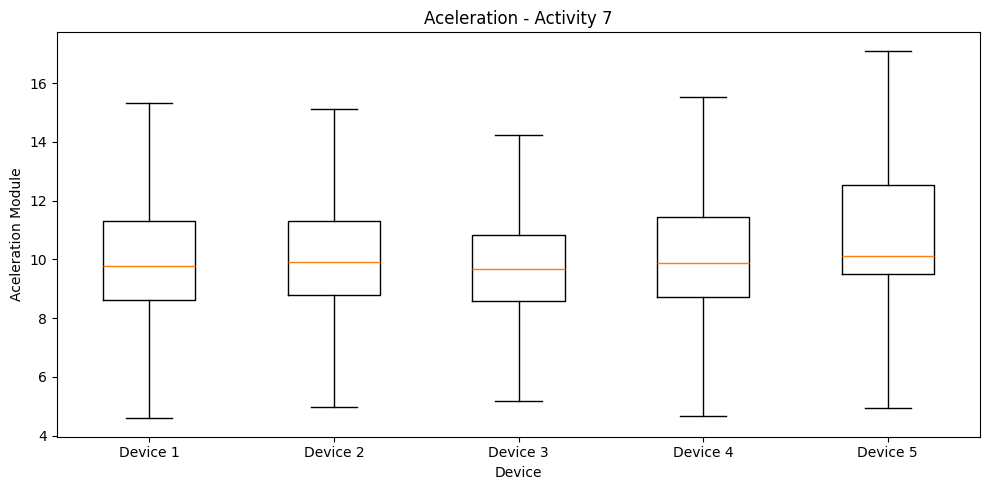

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


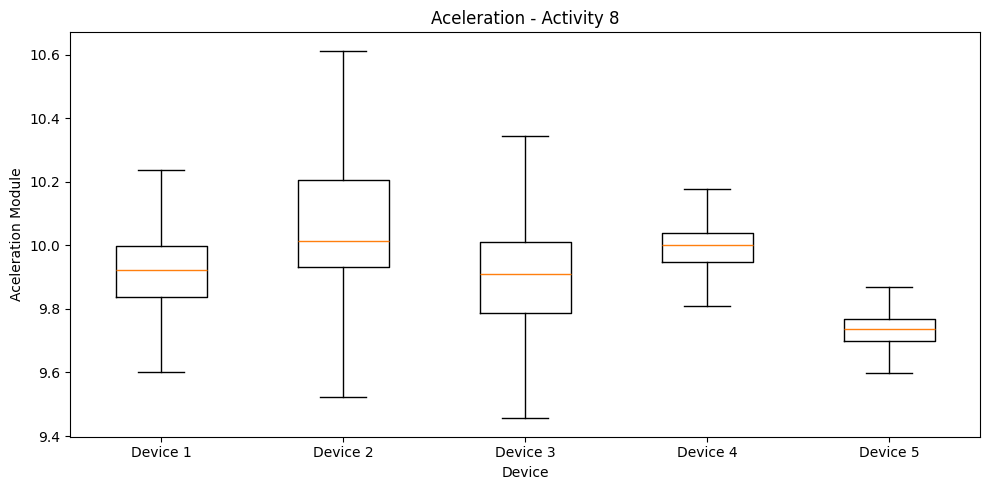

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


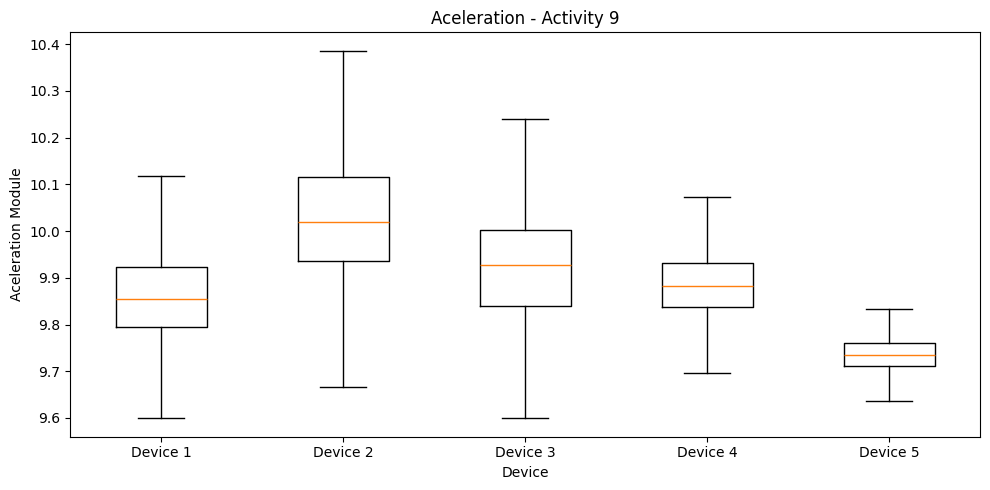

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


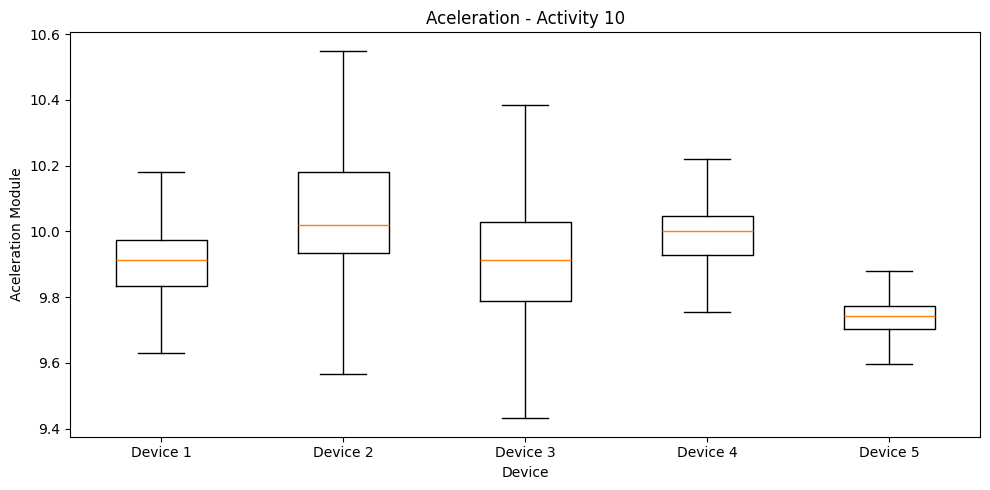

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


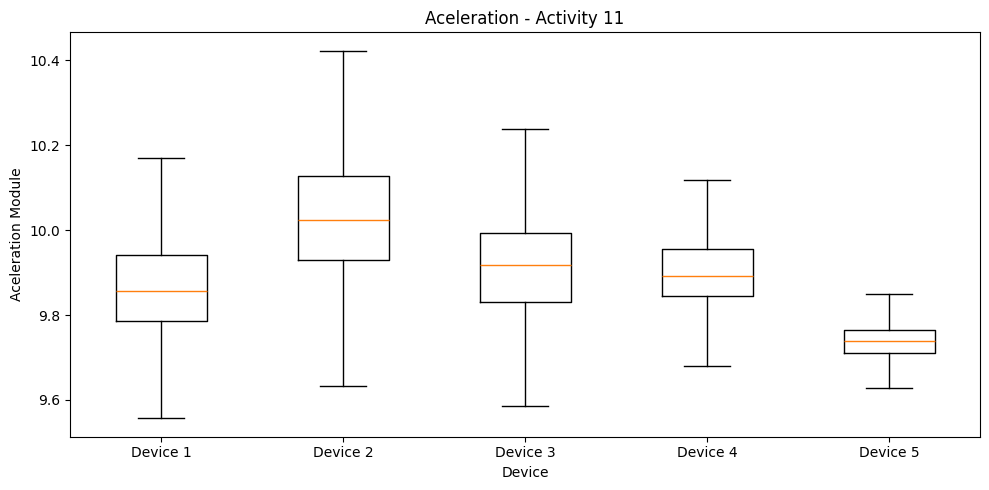

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


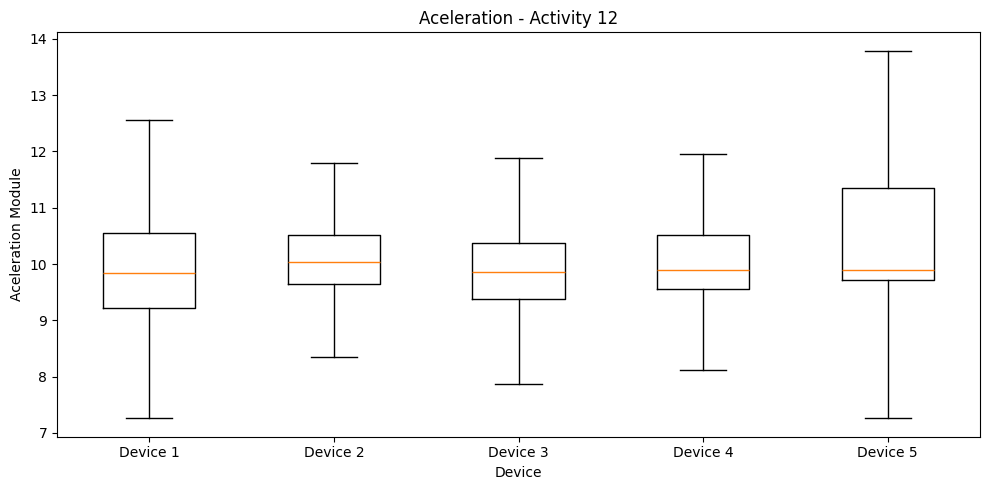

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


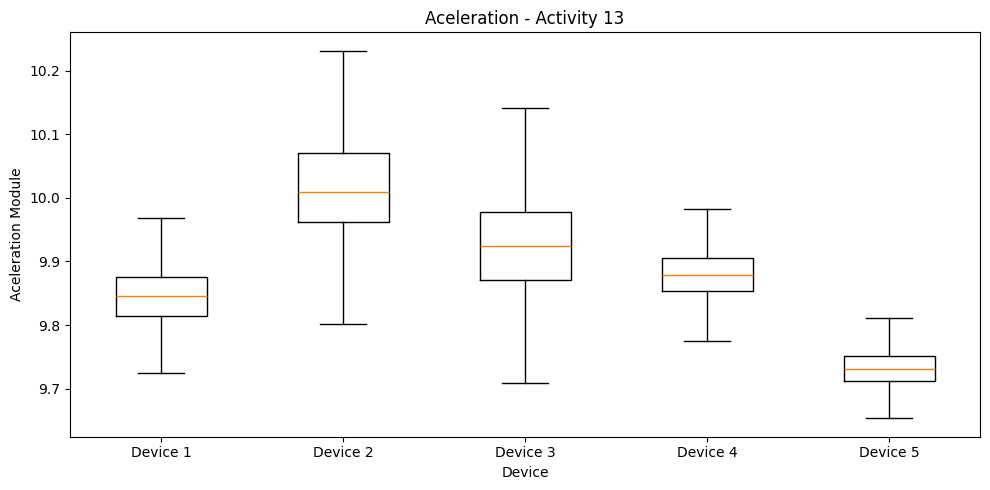

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


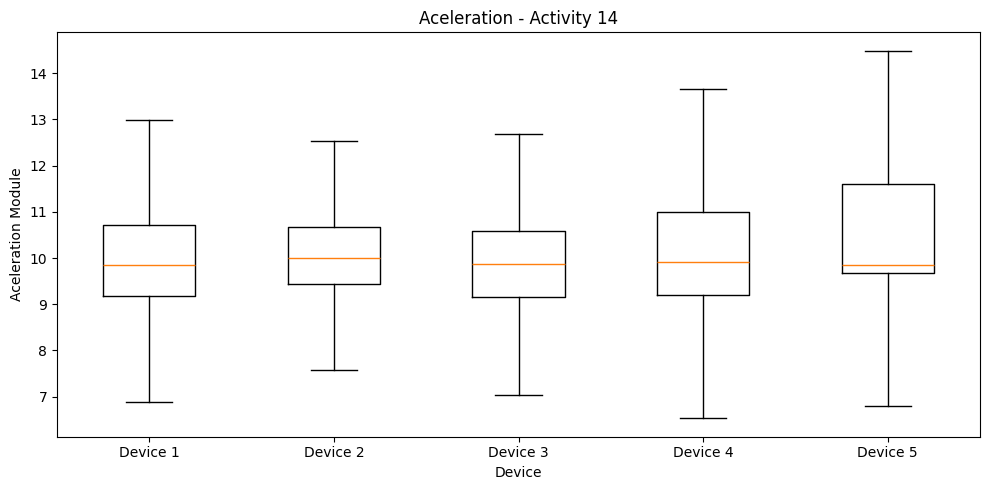

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


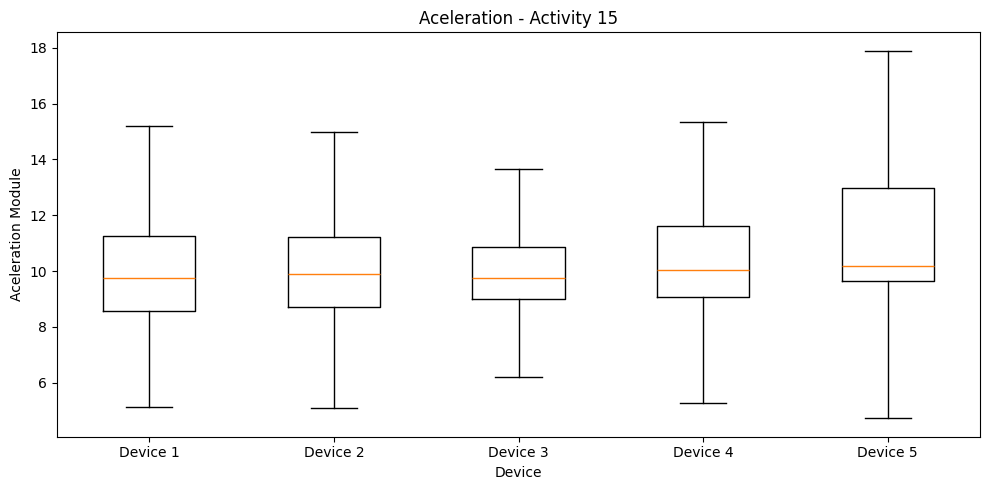

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


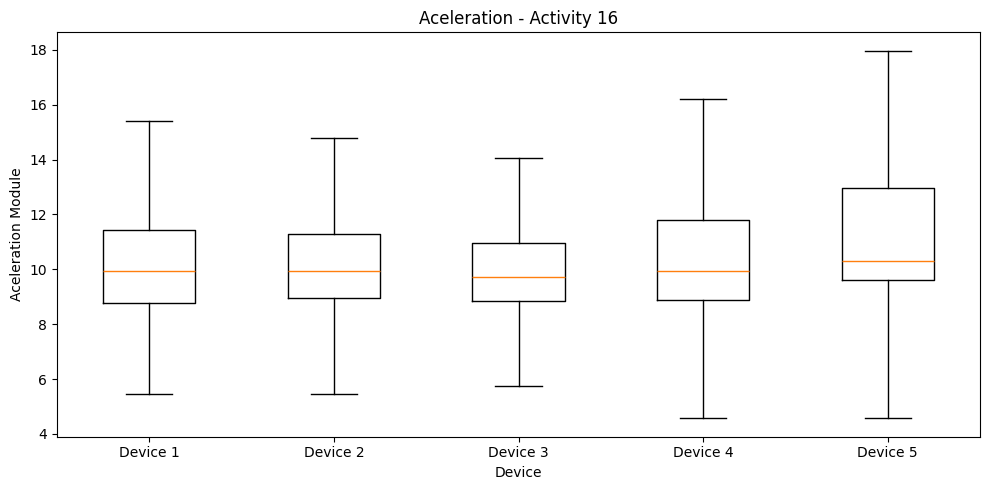

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


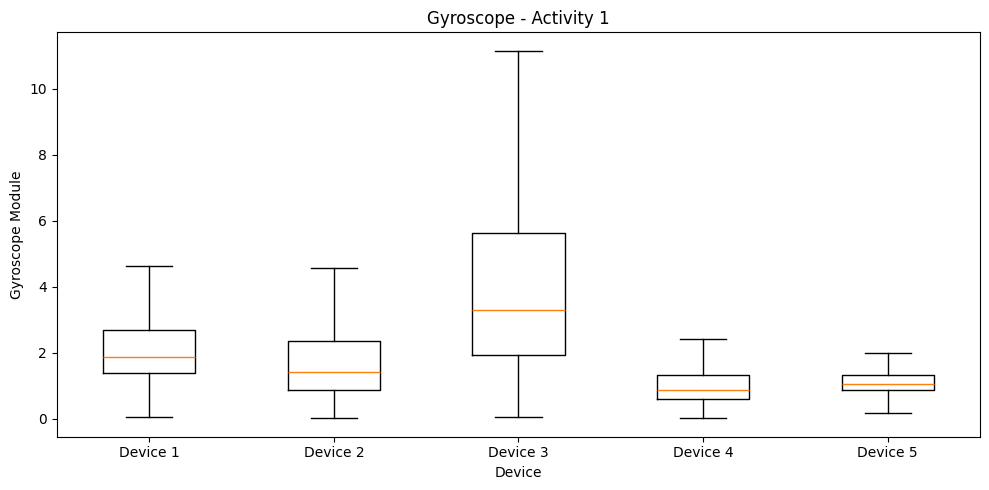

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


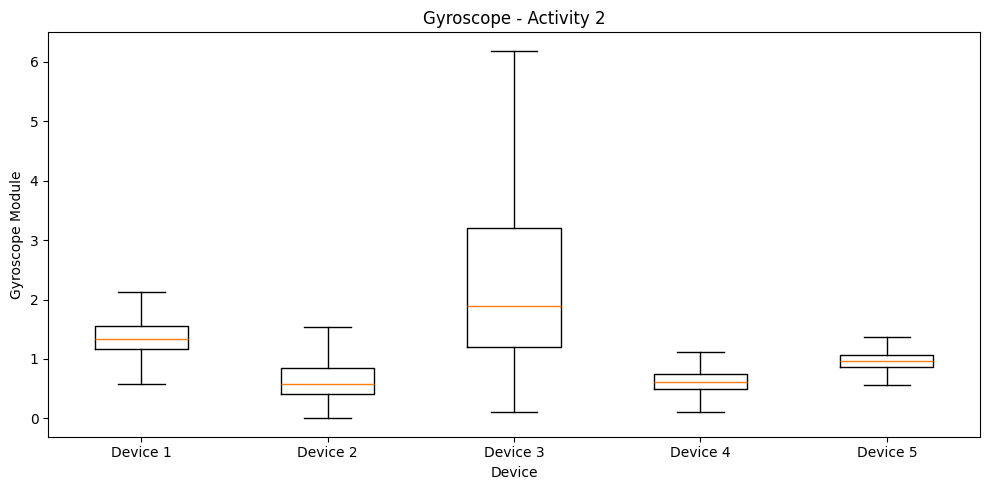

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


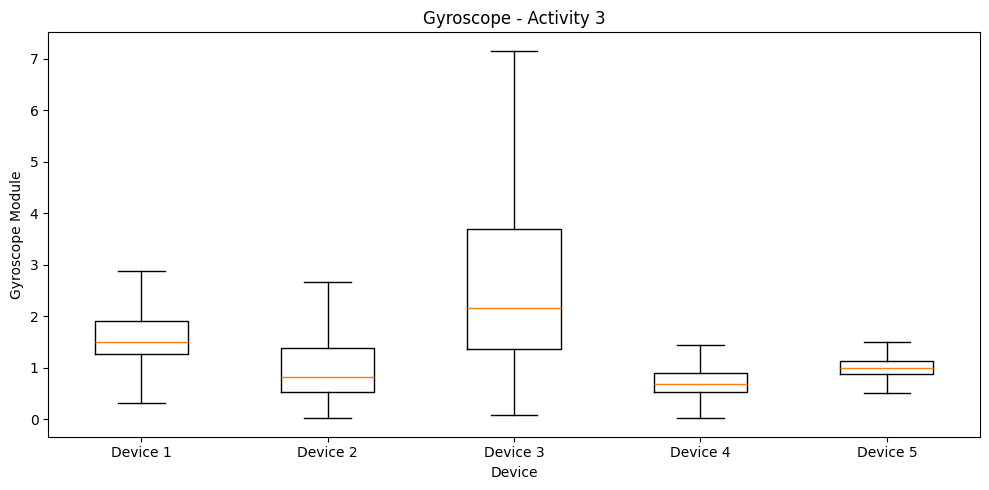

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


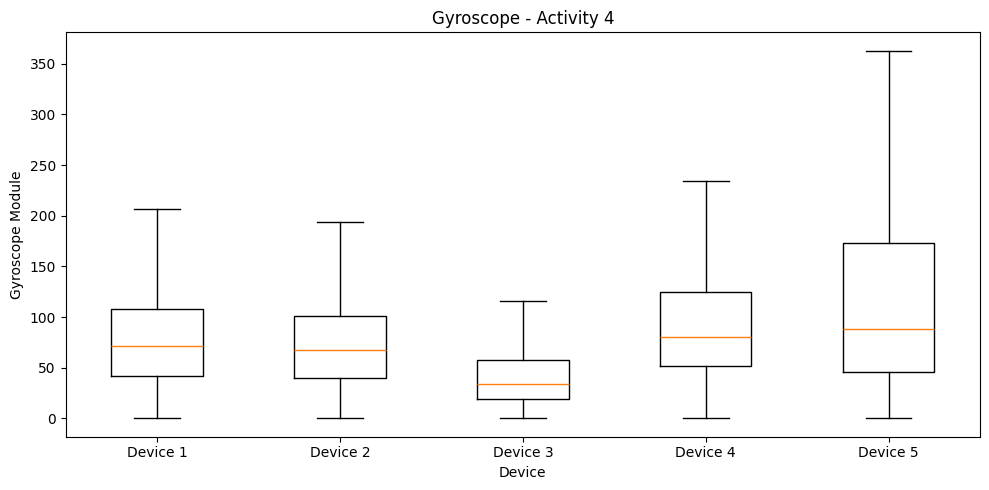

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


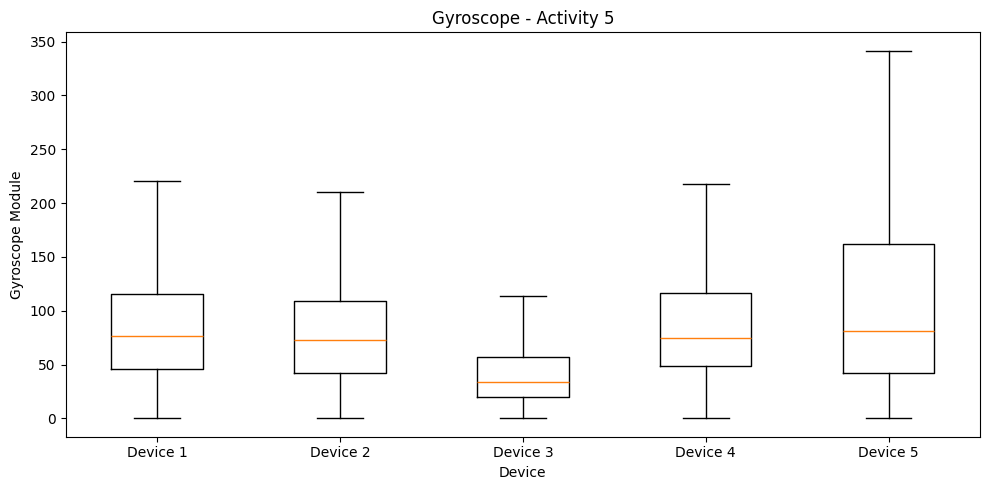

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


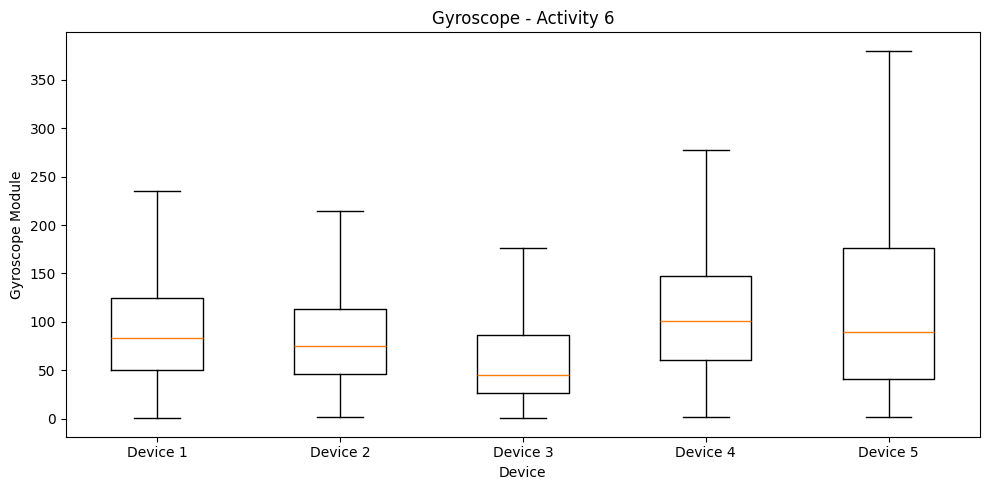

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


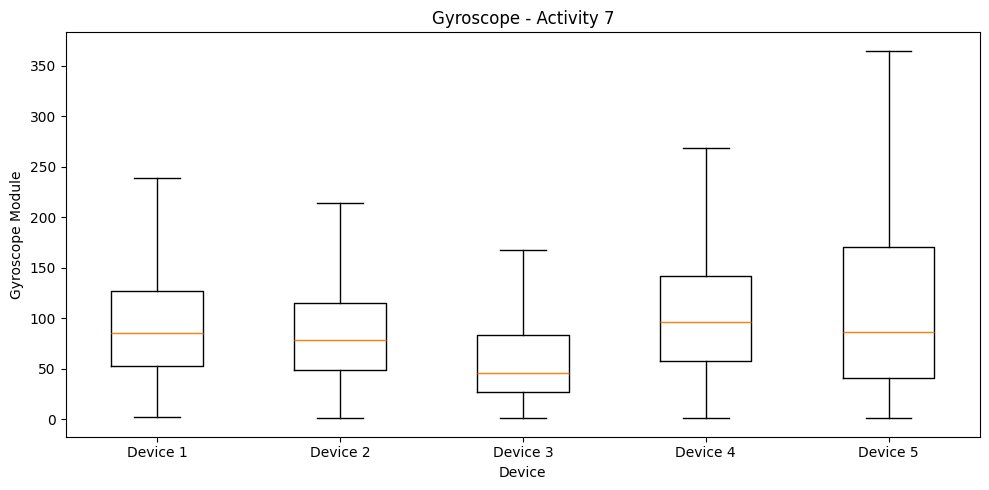

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


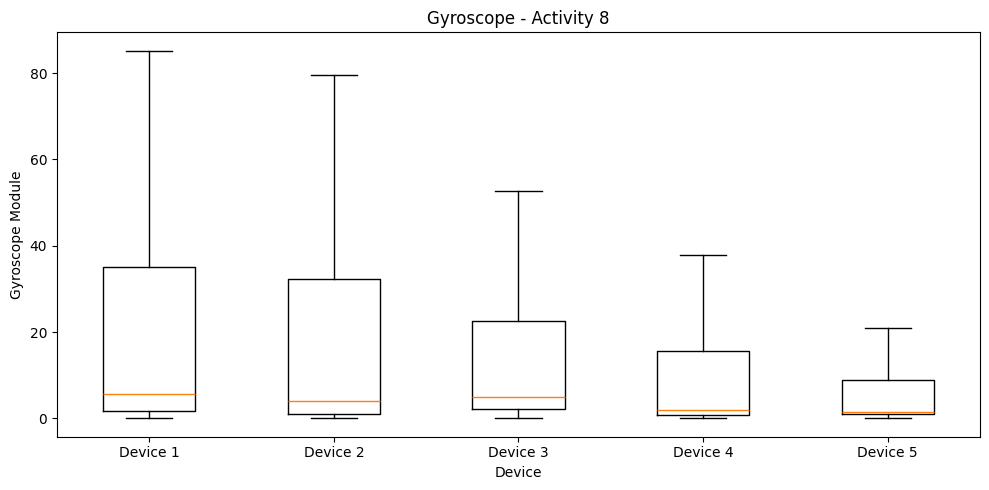

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


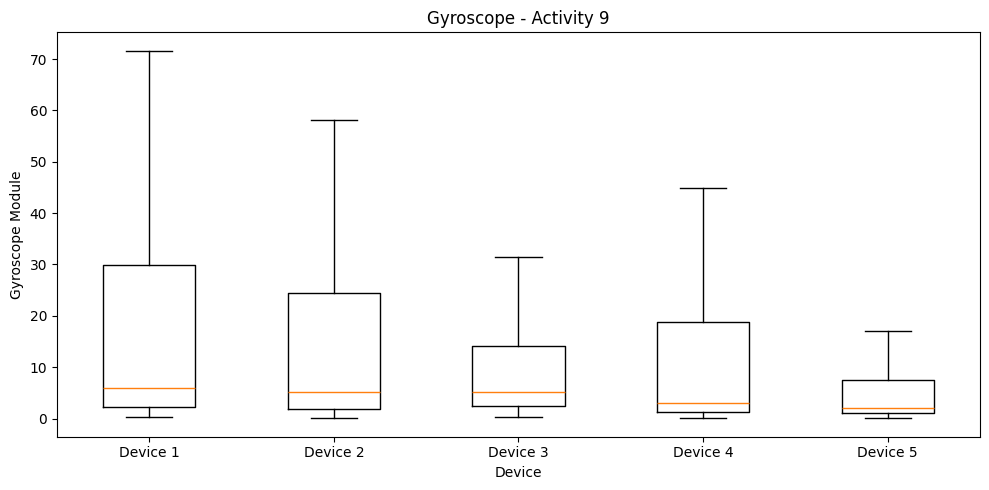

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


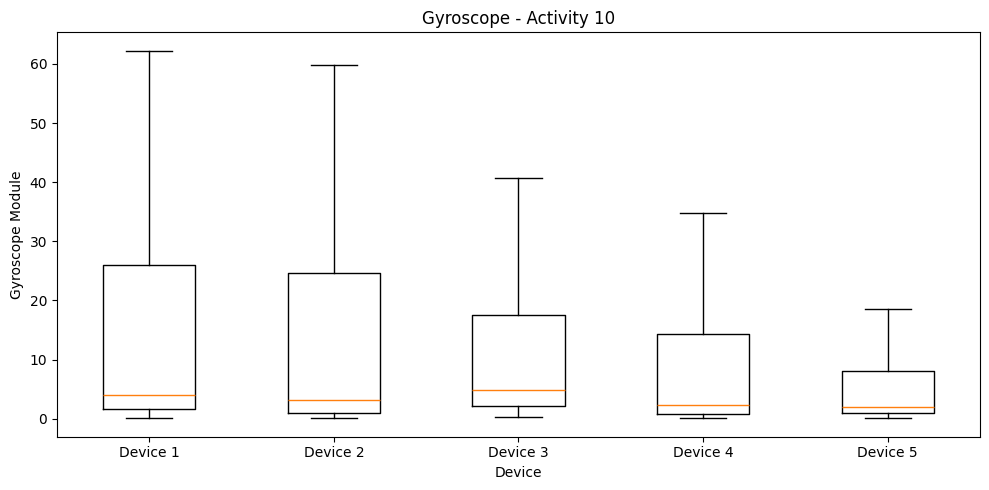

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


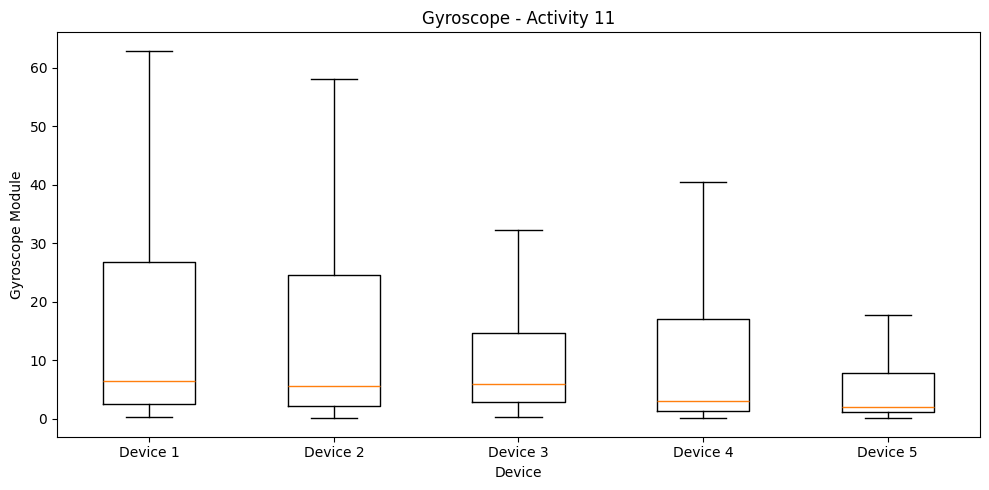

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


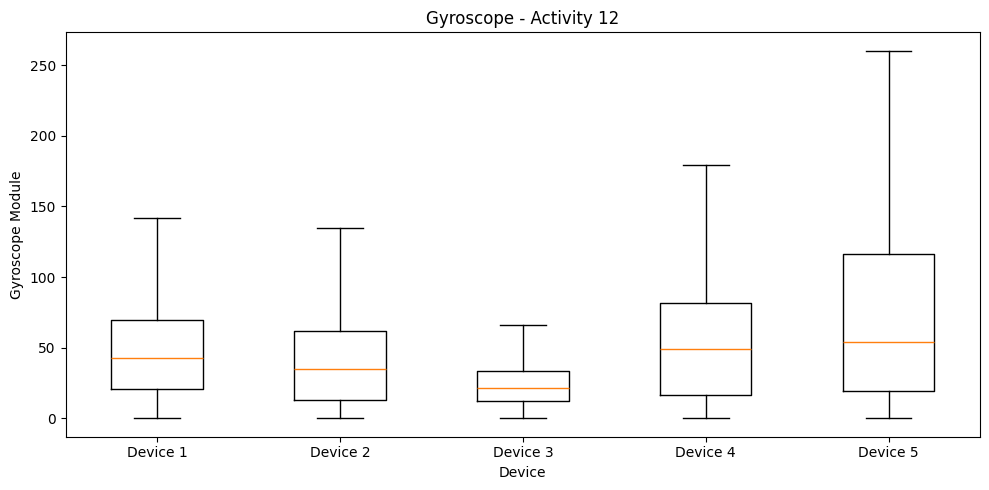

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


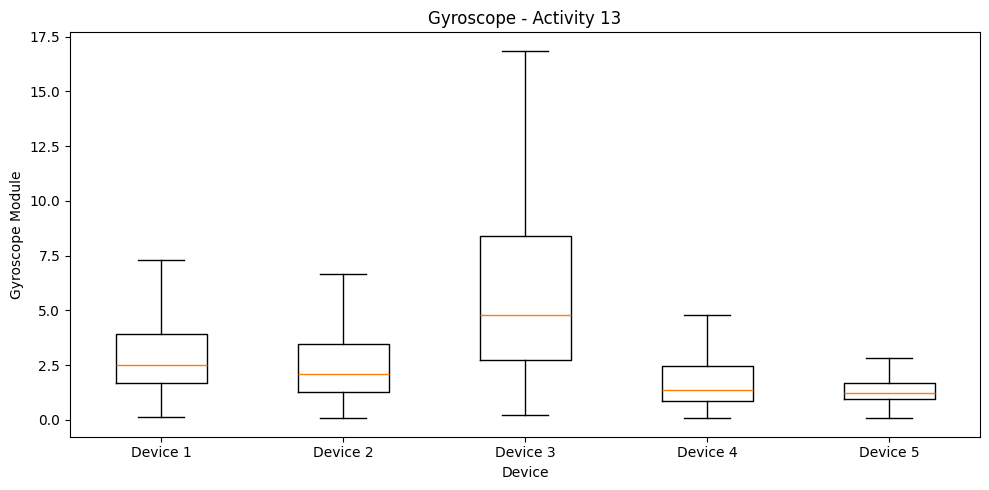

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


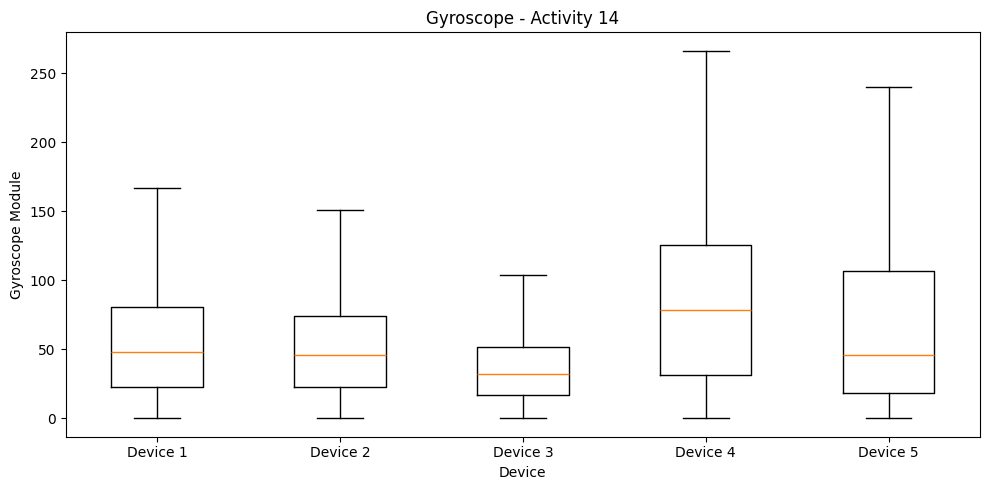

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


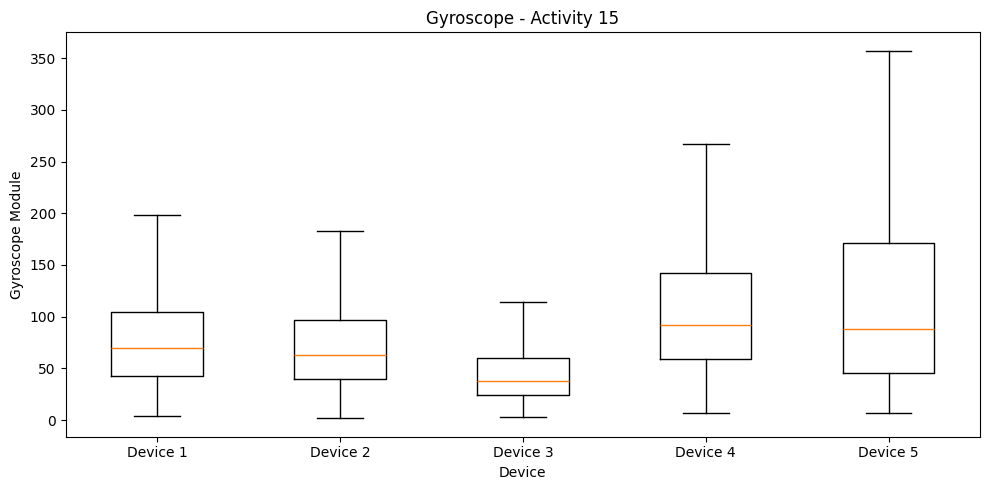

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


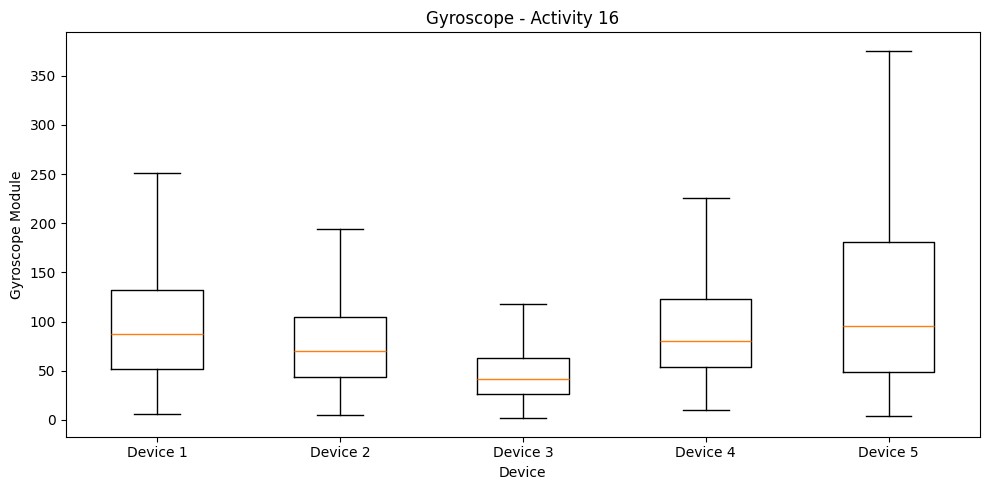

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


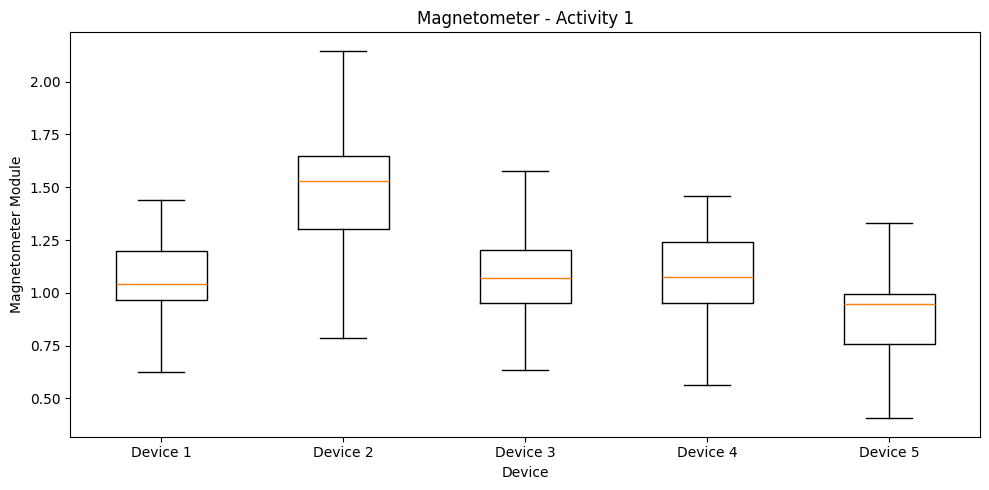

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


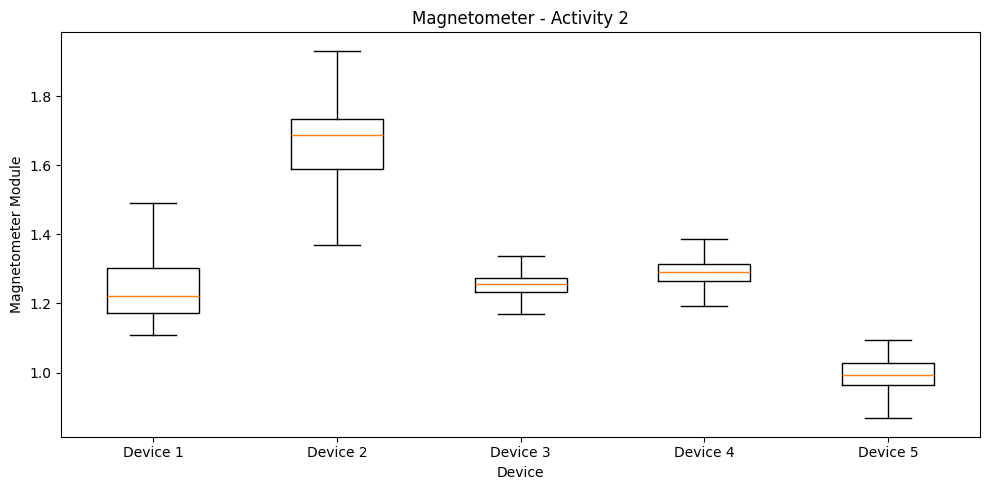

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


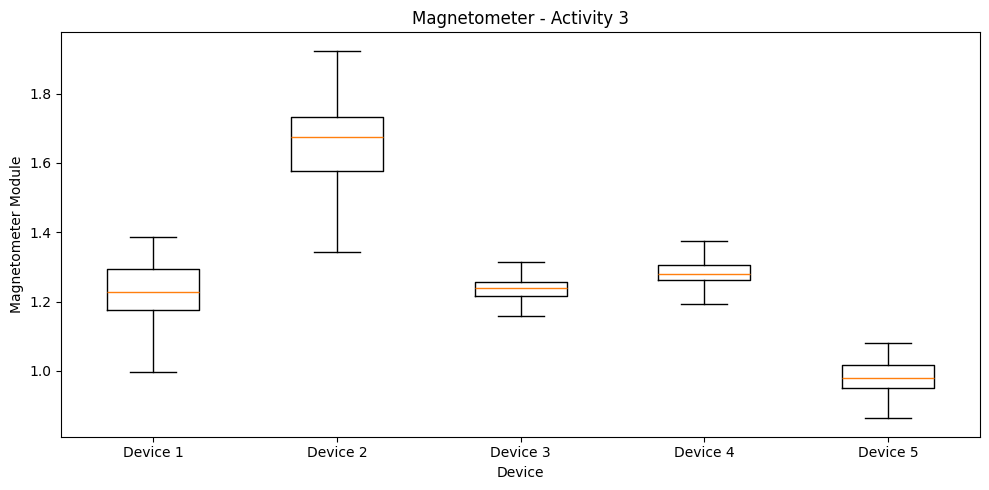

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


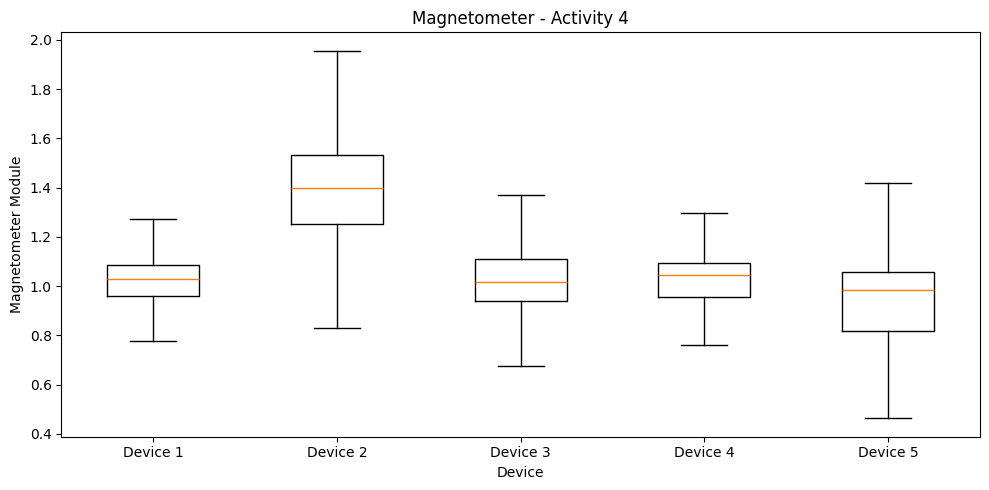

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


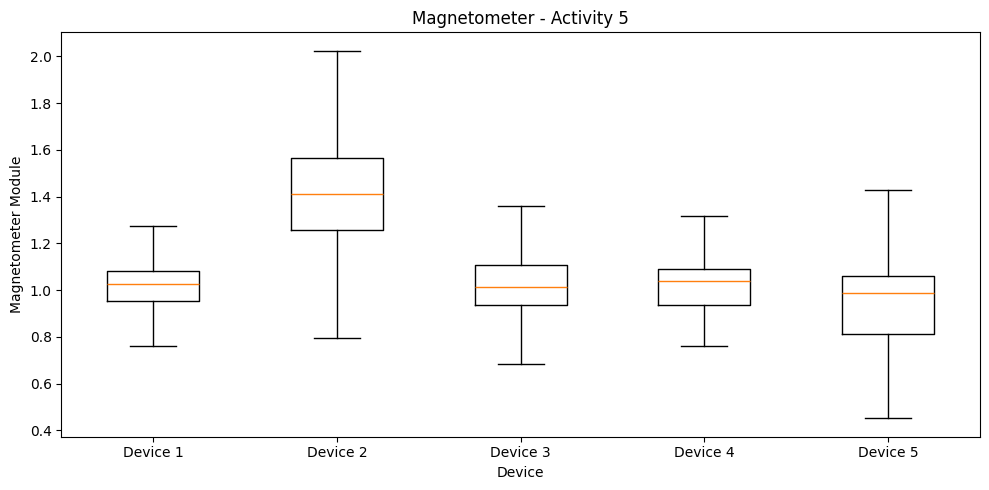

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


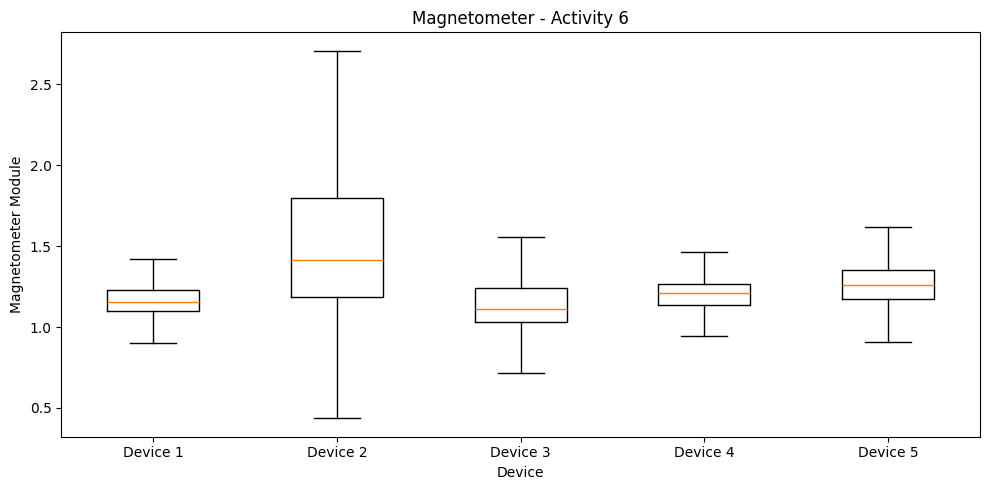

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


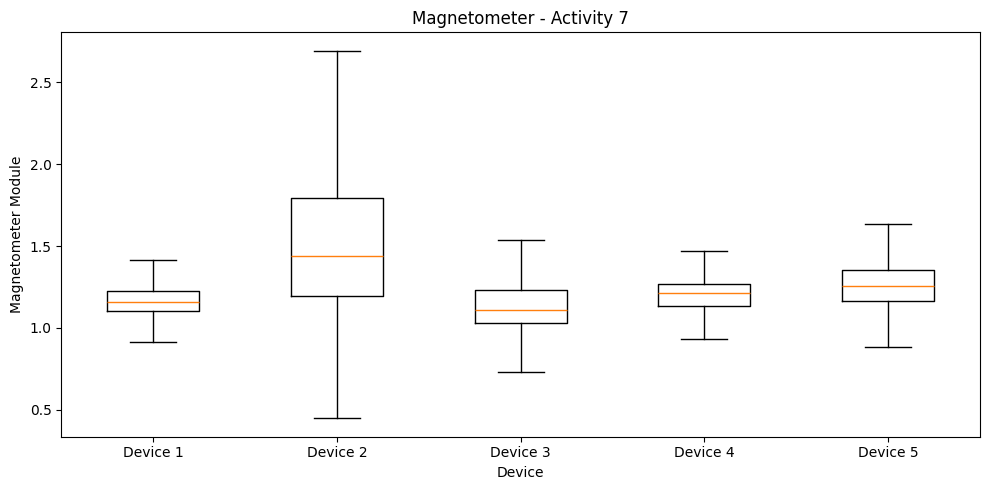

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


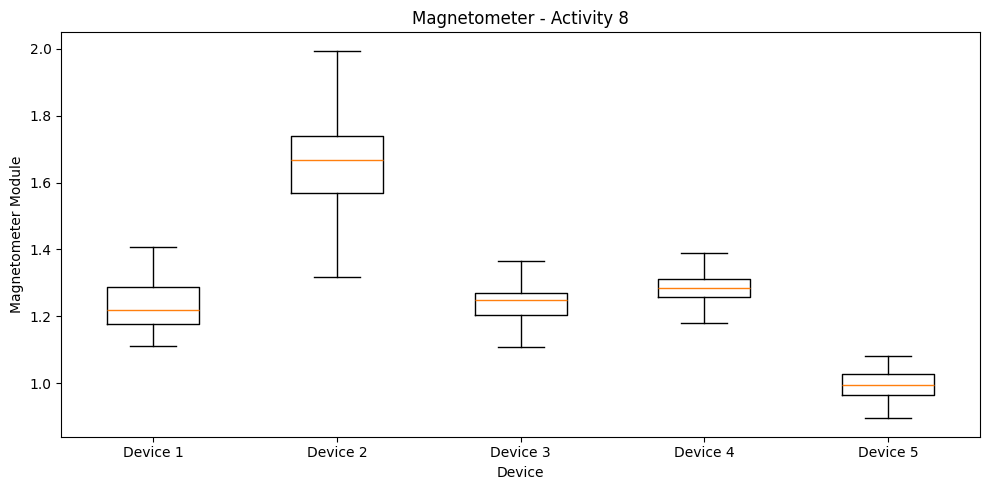

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


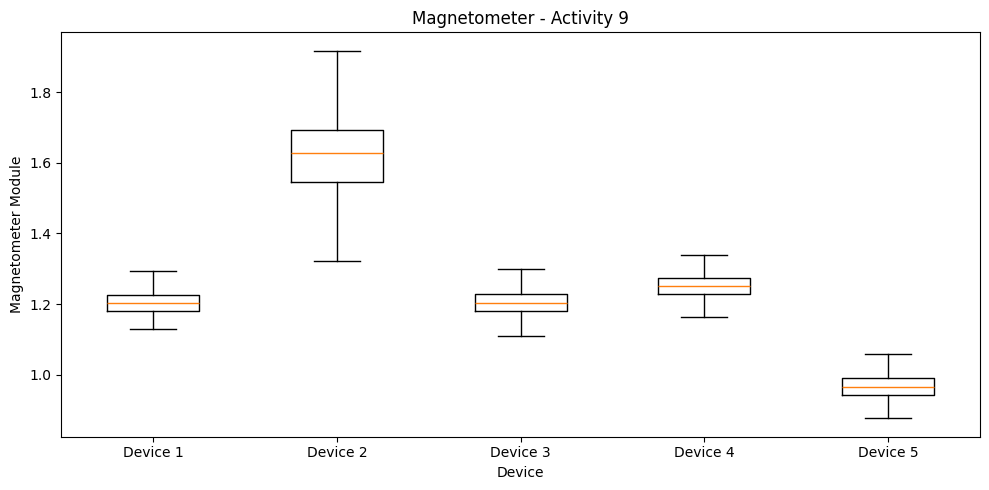

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


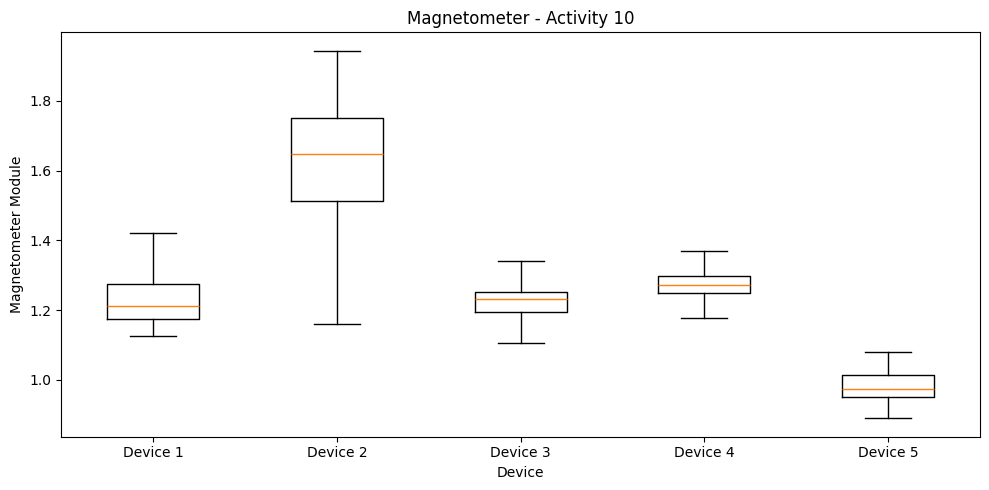

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


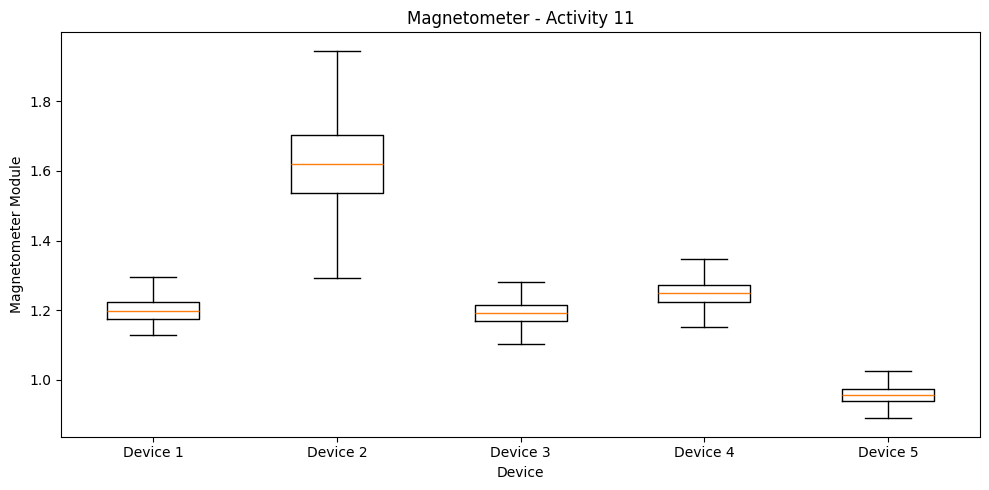

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


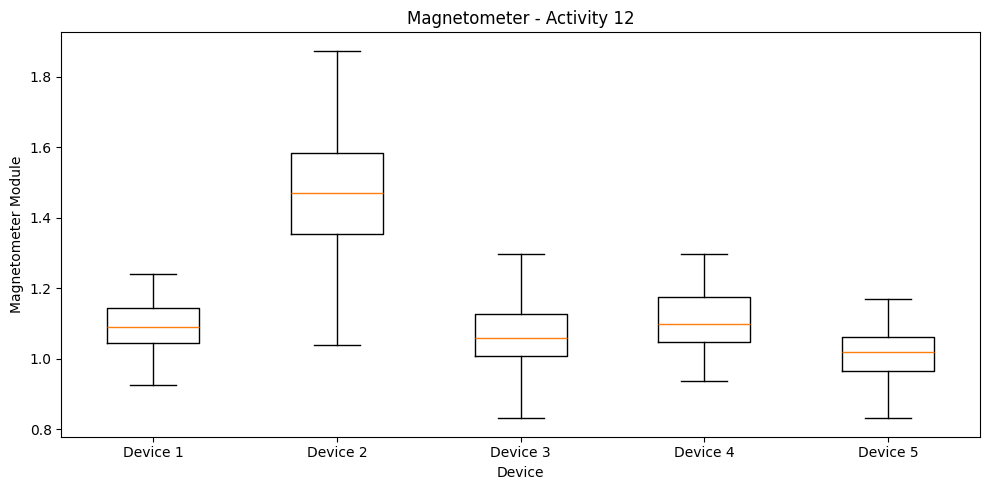

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


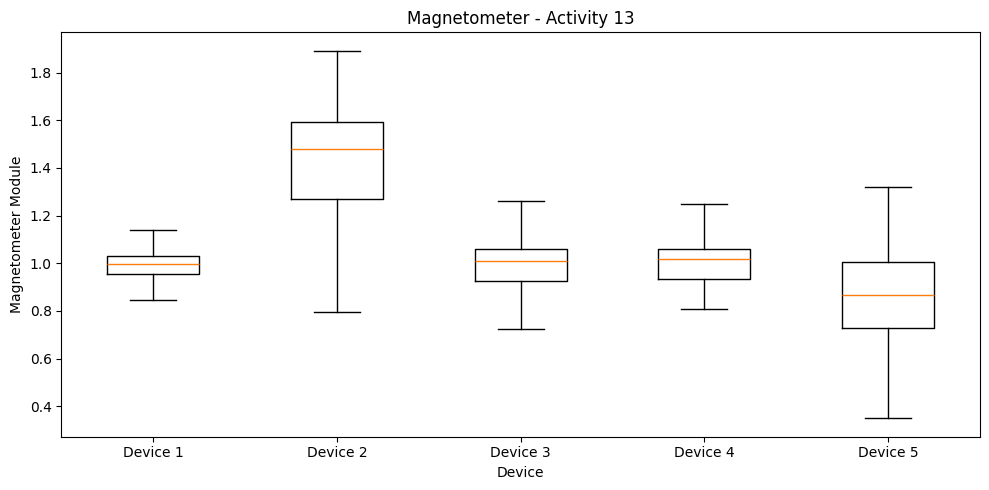

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


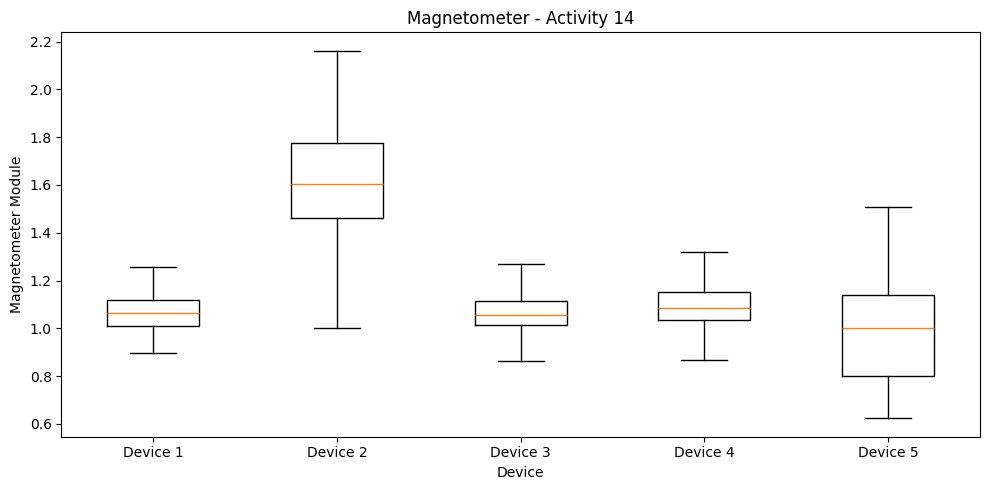

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


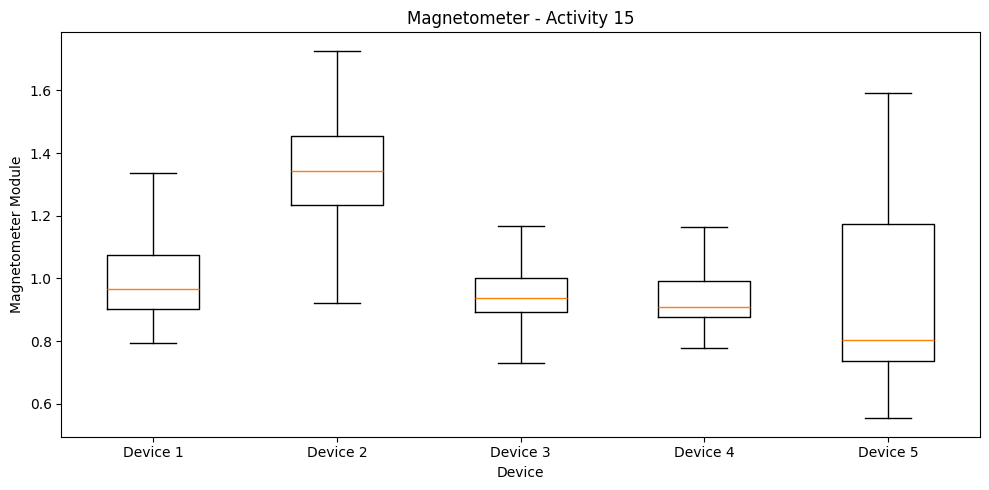

/tmp/ipykernel_7775/1770196865.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=labels, showfliers=False)


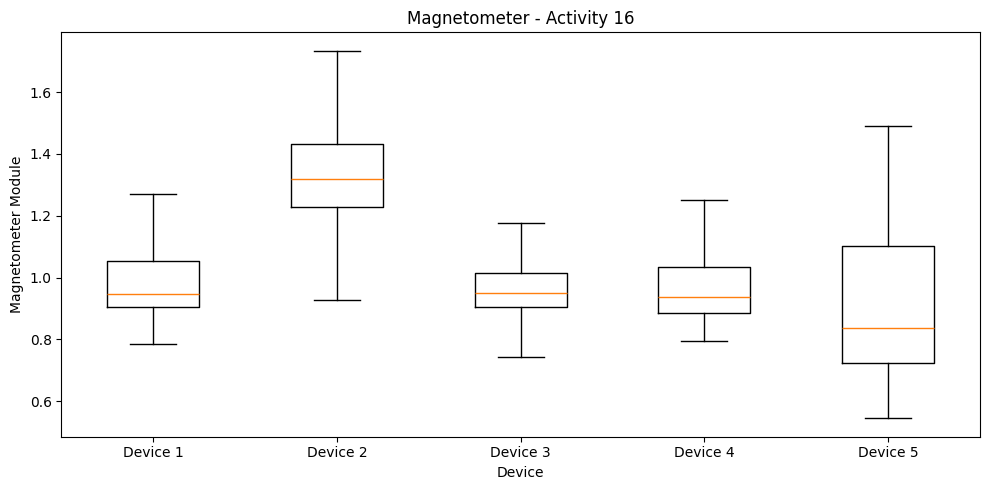

In [6]:
module_boxplots(data, 1)
module_boxplots(data, 2)
module_boxplots(data, 3)

  ## Observações:
  ### Geral:
  Existe uma grande presença de outliers em todos os sensores, o que é visível em praticamente todas as atividades. Sugere que os movimentos humanos contêm variações extremas? É necessário aprofundar a análise para perceber se estes outliers são de facto variações extremas ou se são erros de medição.
  ### Aceleração:
  #### Módulo Aceleração:
  - As atividades estáticas (1, 2, 3) apresentam uma mediana próxima de 10, que correspondem, aproximadamente, à aceleração da gravidade (~9.81 m/s²), com uma variabilidade muito reduzida(caixas pequenas). Isto indica que o corpo está maioritariamente em repouso.
  - As atividades dinâmicas (4,5,6,7) apresentam maior dispersão. Isto reflete a constante variação de aceleração inerente a estas atividades.
  #### Conclusão:
  - Os resultados são os esperados. O módulo da aceleração parece ser uma característica útil para distinguir entre atividades estáticas e dinâmicas.
  ### Giroscópio:
  #### Módulo Giroscópio:
  - Nas atividades estáticas, a mediana está praticamente a zero e a caixa é quase inexistente, indicando pouca ou nenhuma rotação. Sem movimento, não existe velocidade angular.
  - Nas atividades dinâmicas os valores de módulo e a dispersão são significativamente maiores, com outliers evidentes.
  #### Conclusão:
  - O giroscópio apresenta a distanção mais clara entre os dois tipos de atividade.
  ### Magnetómetro:
  #### Módulo Magnetómetro:
  - Existe uma enorme quantidade de outliers nas atividades 6 (Climb Stair) e 7 (Climb Stair and talk). Esse fenómeno provavelmente não se deve ao movimento em si, mas sim ao facto de escadas conterem frequentemente estruturas metálicas (corrimões, vigas, etc.) que podem interferir com o sensor magnético.
  - As atividades estáticas apresentam uma mediana
  #### Conclusão:
  - Ao contrário dos outros sensores, o magnetómetro não mostra uma distinção tão óbvia entre a maioria das atividades estáticas e dinâmicas. As medianas e os intervalos interquartis são relativamente semelhantes entre muitas das atividades. Mas em contrapartida, o magnetómetro pode ser um indicador de uma atividade relacionada com escadas, devido à quantidade de outliers observados.

### Exercício 3.2
Analise e comente a densidade de outliers existentes no dataset transformado, isto é, nos módulos dos vetores aceleração, giroscópio e magnetómetro para cada atividade (use somente os sensores do pulso direito). Observe que a densidade é determinada recorrendo:
$$ d = \frac{no}{nr} * 100 $$
em que no é o número de pontos classificados como outliers e nr é o número total de pontos.

In [7]:
def outliers_density(data, sensor):
    #Only remove data from device id 2
    # dr = (number of outliers / total number of samples) * 100
    device_id = 2
    device_data = data[data[:,1] == device_id]
    #total_num_samples = device_data.shape[0]
    
    #acel
    if sensor == 1:
        c = (2,3,4)
        label = 'Aceleration'
    # giro
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    #magn
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 0, 1, or 2")
    # UTILIZAR TUKEY RULE PARA DETEÇÃO DE OUTLIERS (OU SEJA, VERIFICAR SE ESTÃO FORA DOS LIMITES)
    
    
    sensor_data= device_data[:, c]
    magnitude= np.linalg.norm(sensor_data, axis=1)
    
    activities= device_data[:,12]
    unique= np.unique(activities)
    results= {}
    outlier_counts=[]
    
    for a in unique: 
        mag = magnitude[activities==a]
    
        
        Q1= np.percentile (mag, 25)
        Q3= np.percentile (mag, 75)
        IQR= Q3-Q1
        lower_limit= Q1-1.5*IQR
        upper_limit= Q3+1.5*IQR
        
        outliers = (mag < lower_limit) | (mag > upper_limit)
        
        nr= len(mag)
        no= np.sum(outliers)
        
        if nr > 0:
            density = (no / nr) * 100
        else:
            density = 0
        
        results[a] = {
            'density': density,
            'total_points': nr,
            'outliers_count': no
        }
        outlier_counts.append(no)
        
        
    plt.figure(figsize=(10,5))
    plt.bar(unique, outlier_counts)
    plt.ylabel('Number of Outliers')
    plt.title(f'Number of Outliers – {label} (Device 2)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()
    
    #return results, label

    

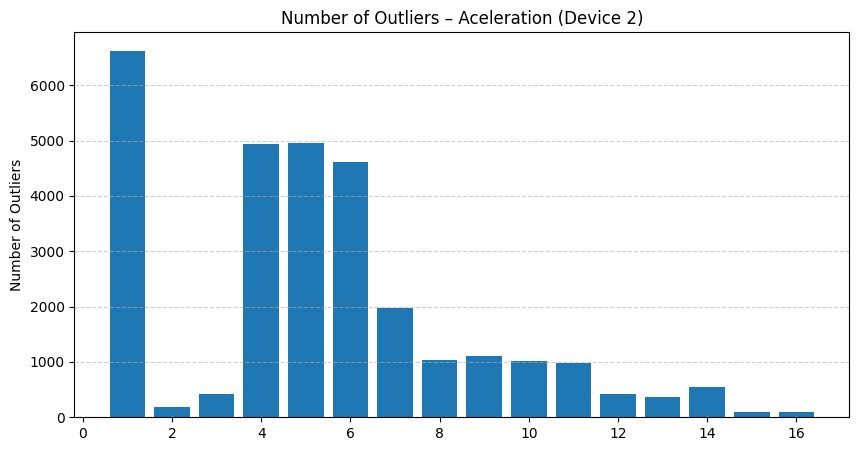

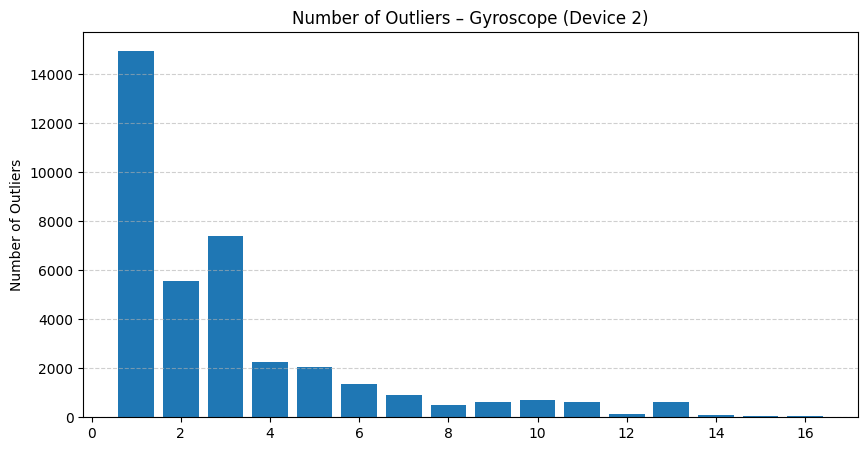

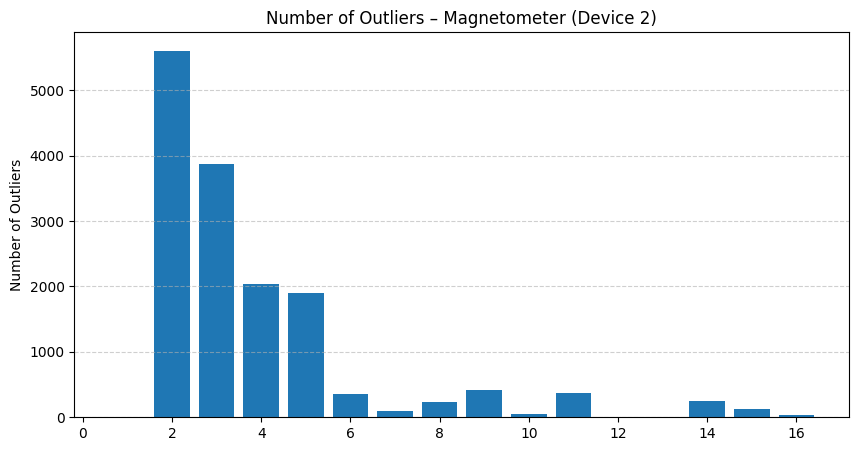

In [8]:
outliers_density(data, 1)
outliers_density(data, 2)
outliers_density(data, 3)

#### Acho que era interessante se tivessemos para além destes gráficos de barras uma tabela, por exemplo, com percentagens de outliers para cada atividade e sensor.

comentar depois, fazer uma observaçao. aqui nao sei mt bem se é p fazer por participante ou atividade, ou seja, nao sei se fiz os graficos be (nao sei s me fiz entender)

### Exercício 3.3
Escreva uma rotina que receba um Array de amostras de uma variável e identifique os outliers usando o teste Z-Score para um k variável (parâmetro de entrada).

In [9]:
def detect_outliers_zscore (samples, k):
    mean= np.mean(samples)
    std= np.std(samples)
    
    z_scores = np.abs((samples - mean) / std)
    
    outliers= z_scores>k
    
    return outliers
    
#exemplo
acc_sample= np.sqrt(data[:, 2]**2 + data[:, 3]**2 + data[:, 4]**2)
acc_outliers = detect_outliers_zscore(acc_sample, k=3)
print (acc_outliers) #quando sai true é outlier


[False False False ... False False False]


### Exercício 3.4
Usando o Z-score implementado, assinale todos as amostras consideradas outliers nos módulos dos vetores de aceleração, giroscópio e magnetómetro.
Apresente plots em que estes pontos surgem a vermelho, enquanto os restantes surgem a azul. Use k=3, 3.5 e 4.

In [10]:
def plot_zscore_outliers (data, sensor, k_values=[3.0,3.5,4.0]):
    if sensor == 1:  
        c = (2, 3, 4)
        label = 'Acceleration'
    elif sensor == 2: 
        c = (5, 6, 7)
        label = 'Gyroscope'
    elif sensor == 3:  
        c = (8, 9, 10)
        label = 'Magnetometer'
        
    mod = np.sqrt((data[:,c]**2).sum(axis=1))
    all = data[:,12]
    unique_activities = np.unique(all).astype(int)
    
    
    for k in k_values:
        plt.figure(figsize=(8,5))
        plt.title(f'{label} - Outliers Z-Score (k={k})')
        
        for i, act in enumerate(unique_activities):
            mod_act = mod[all == act]
            out = detect_outliers_zscore(mod_act, k)
            
            # Pontos normais em azul
            normais = mod_act[out == False]  # pega apenas os que não são outliers
            plt.scatter([i+1]*len(normais), normais, color='blue', s=20)

            # Outliers em vermelho
            outliers = mod_act[out == True]  # ou simplesmente mod_act[out]
            plt.scatter([i+1]*len(outliers), outliers, color='red', s=40)

        plt.xlabel('Atividade')
        plt.ylabel('Módulo')
        plt.xticks(range(1, len(unique_activities)+1), unique_activities)
        plt.show()

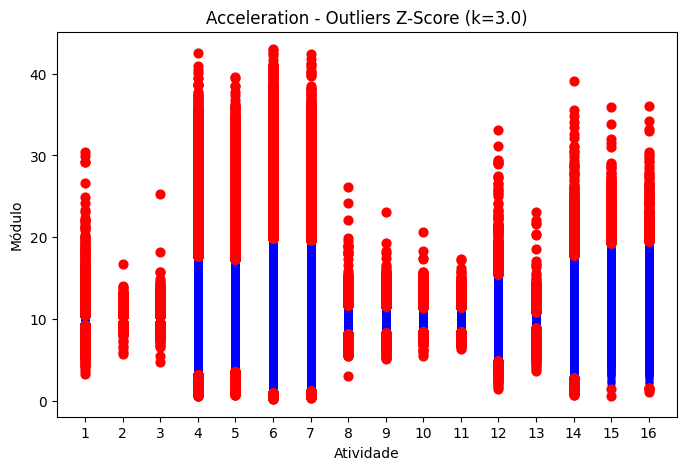

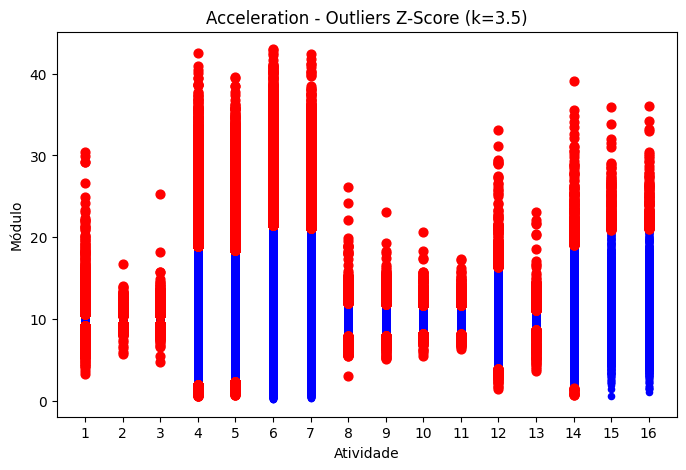

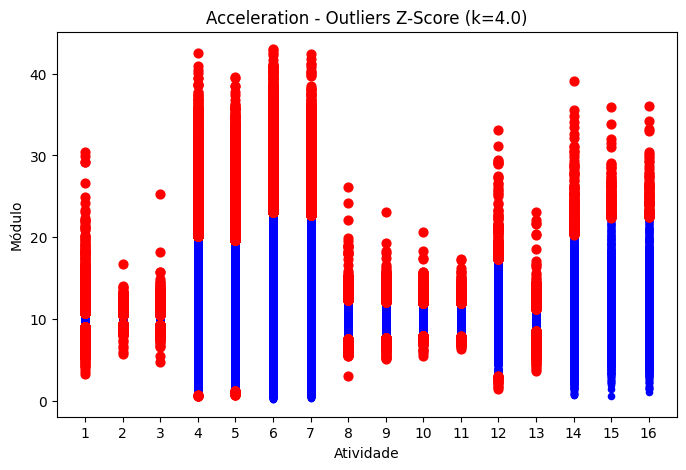

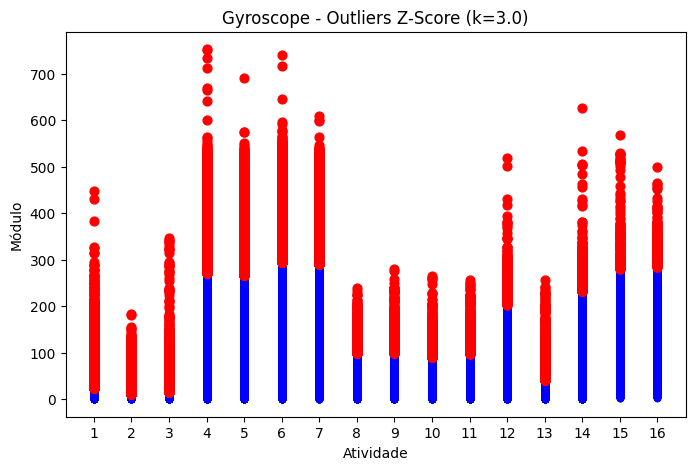

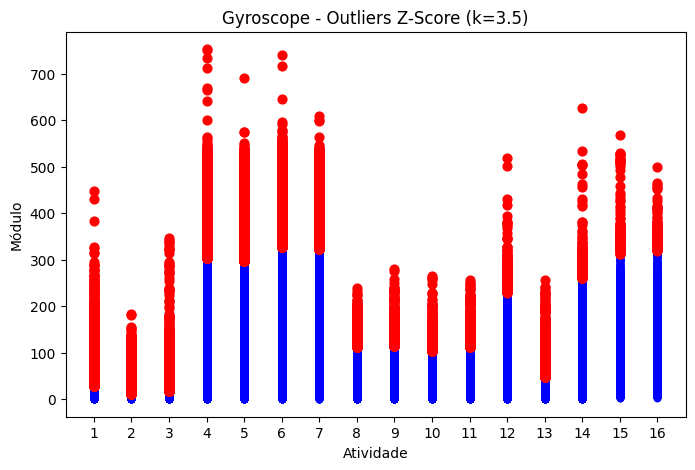

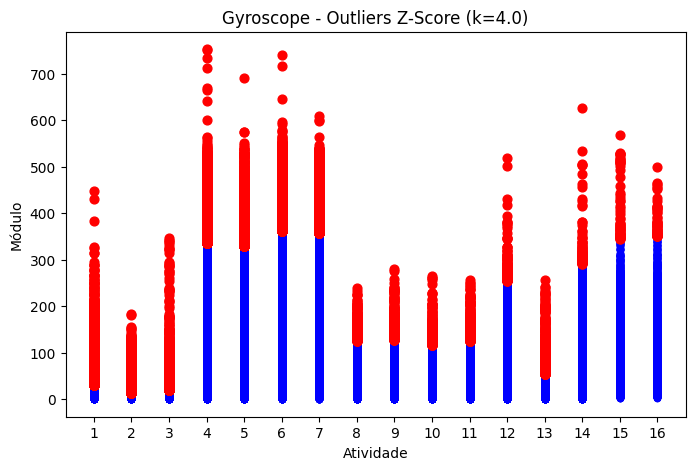

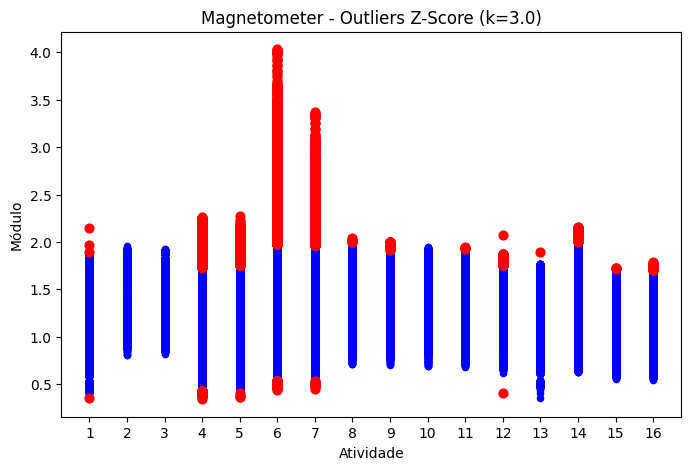

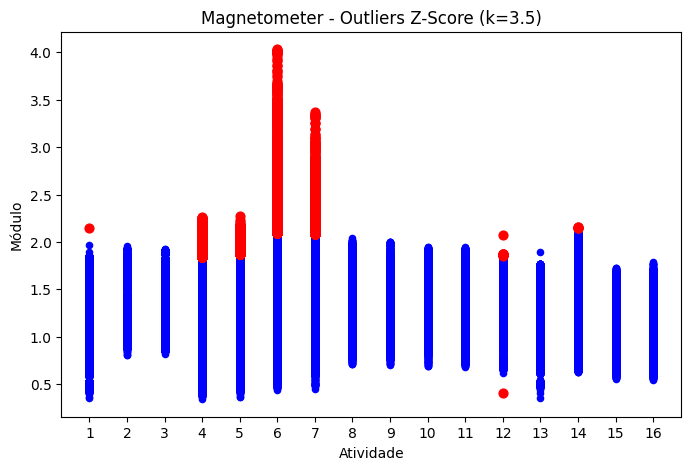

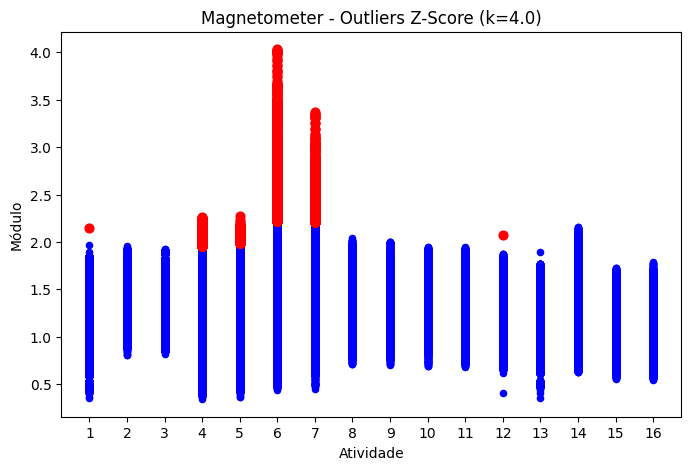

In [12]:
plot_zscore_outliers(data, sensor=1)  # Aceleração
plot_zscore_outliers(data, sensor=2)  # Giroscópio
plot_zscore_outliers(data, sensor=3)  # Magnetômetro

### Observações
#### Análise dos Gráficos Z-Score (Exercício 3.4)
Os gráficos 2D do Z-Score mostram os outliers (a vermelho) identificados em cada atividade, com base no módulo de cada sensor (aceleração, giroscópio e magnetómetro)
##### Observação do k:
Como se pode observar nos gráficos, o valor de k funciona como um limiar de tolerância.
- Com k = 3.0 (tolerância baixa), o método é muito rigoroso e marca uma grande quantidade de pontos como outliers, especialmente em atividades dinâmicas.
- Com k = 3.5 (tolerância média), o número de outliers detetados diminui, mas ainda é considerável, refletindo a variabilidade natural dos movimentos humanos.
- Com k = 4.0 (tolerância alta), o número de outliers detetados diminui significativamente, pois o limiar para considerar um ponto anómalo é mais elevado.
##### Limitações do Z-Score:
O Z-Score baseia-se na média e no desvio-padrão de toda a atividade. Em movimentos humanos, que têm naturalmente uma alta variabilidade, muitos pontos que são picos normais do movimento acabam por ser marcados como outliers. Ele apenas vê a magnitude sem considerar o contexto.

### Exercício 3.5
#### Compare e discuta os resultados obtidos em 3.1 e 3.4. 

## Observações:
  ### Geral:
- A comparação revela que atividades com maior variabilidade visual nos gráficos 3.1 correspondem a maior número de outliers nas análises 3.4.
- O método Z-Score é eficaz para identificar desvios extremos, mas pode ser excessivamente sensível para dados de movimento humano
- Há medida que o k aumenta, menos filtra os outliers
  ### Aceleração:
  #### Módulo Aceleração:
  - Atividades com maior variabilidade na 3.1 (como 8, 9, 10, 11, 12) mostram dispersão significativa entre dispositivos nos valores do módulo, o que se reflete em mais outliers na 3.4
  - Atividades com menor variabilidade na 3.1 (como 1, 2, 3, 4), apresentam padrões mais consistentes entre dispositivos e menor amplitude de variação, resultando em menos outliers na 3.4
  - Dispositivos como o 3 e o 4 mostram padrões consistentemente diferentes dos outros em múltiplas atividades nas 3.1, contribuindo para os outliers nas 3.4
  #### Conclusão:
  - A análise 3.4 com Z-Score valida quantitativamente as observações qualitativas das figuras 3.1
  - Atividades que visualmente mostram maior inconsistência entre dispositivos nas 3.1 são corretamente identificadas como tendo mais outliers na 3.4
  ### Giroscópio:
  #### Módulo Giroscópio:
  - 6 a 12 apresentam picos extremos de outliers na 3.4 indicando movimentos rotacionais intensos e complexos
  - 1 a 5 mostram baixíssima contagem de outliers (0-100), refletindo movimentos rotacionais básicos ou quase inexistentes
  - A transição abrupta entre 5 e 6 revela uma mudança drástica no padrão de movimento, passando de estabilidade para rotatividade intensa
  - 3 e 4 demonstram inconsistências marcantes nas atividades de maior intensidade rotacional (6-12), com trajetórias claramente divergentes dos outros dispositivos
  - A atividade 8 destaca-se pela ausência de dados do módulo na 3.1, sugerindo possíveis falhas de medição que se refletem na análise de outliers
  #### Conclusão:
  - O giroscópio gera muito mais outliers que outros sensores devido à natureza dos movimentos rotacionais
  ### Magnetómetro:
  #### Módulo Magnetómetro:
  - A consistência visual observada nas figuras 3.1, onde todos os dispositivos mostram trajetórias sobrepostas e padrões uniformes, reflete-se diretamente nos valores mínimos de outliers nas análises 3.4
  - 1 a 16 apresentam valores consistentemente baixos de outliers nas análises 3.4, com todos os valores abaixo de 0.5, indicando alta estabilidade nas medições
  - Não se observam picos significativos de outliers em nenhuma atividade específica, ao contrário do verificado nos outros sensores
  #### Conclusão:
  - O magnetómetro estabelece um padrão de referência para qualidade de dados, contra o qual podem ser comparados o desempenho do giroscópio e acelerómetro



### Exercício 3.6
Elabore uma rotina que implemente o algoritmo k-means para n (valor de entrada) clusters.
#### Explicação da rotina implementada:
A rotina implementada para o algoritmo k-means segue os passos:
1. Inicialização: São selecionados `n_clusters` centróides iniciais aleatoriamente a partir dos dados.
2. Atribuição: Cada ponto no dataset data é iterativamente comparado com todos os centróides atuais. A distância Euclidiana (np.linalg.norm) é calculada entre o ponto e cada centróide. O ponto é então atribuído ao cluster cujo centróide se encontra mais próximo (menor distância).
3. Atualização: Os centróides são recalculados como a média dos pontos atribuídos a cada cluster. Para evitar erros, se um cluster ficar temporariamente vazio (nenhum ponto atribuído), o seu centróide é re-inicializado aleatoriamente a partir do dataset original.
4. Convergência: Os passos de atribuição e atualização são repetidos. O algoritmo termina quando:
- A mudança na posição de todos os centróides entre uma iteração e a seguinte é muito pequena (inferior a uma tolerância `tol`).
- O número de repetições atinge o limite `max_iter`.

In [3]:
def kmeans (data, n_clusters, max_iter=100, tol=1e-4):
    centroids= data[np.random.choice(data.shape[0], n_clusters, replace=False)]
    
    for i in range(max_iter):
        labels = np.zeros(data.shape[0], dtype=int)
        
        # Passo 1: atribui cada ponto ao cluster mais próximo
        for m, point in enumerate(data):
            min_dist = float('inf')
            for k in range(n_clusters):
                dist = np.linalg.norm(point - centroids[k])
                if dist < min_dist:
                    min_dist = dist
                    labels[m] = k
                    
        # Passo 2: atualiza centróides
        new_centroids = np.zeros_like(centroids)
        for k in range(n_clusters):
            cluster_points = data[labels == k]
            if len(cluster_points) > 0:
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                # Se algum cluster ficar vazio, reposiciona aleatoriamente
                new_centroids[k] = data[np.random.choice(data.shape[0])]
        
        if np.all(np.linalg.norm(new_centroids - centroids, axis=1) < tol):
            break
        
        centroids = new_centroids
    
    return labels, centroids
            

In [4]:
def analyze_sensor_data(data, n_clusters=3, max_iter=100, tol=1e-4):
    device = data[:, 1].astype(int)
    activities = data[:, 12].astype(int)
    
    sensors = {
        1: (2, 3, 4, 'Acceleration'),
        2: (5, 6, 7, 'Gyroscope'), 
        3: (8, 9, 10, 'Magnetometer')
    }
    
    # Criar subplots
    n_plots = len(np.unique(device)) * len(sensors) * len(np.unique(activities))
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()
    plot_idx = 0
    
    for sensor_id, (start, mid, end, sensor_name) in sensors.items():
        for dev in np.unique(device):
            for activity in np.unique(activities):
                # Filtrar dados
                mask = (device == dev) & (activities == activity)
                sensor_data = data[mask, start:end+1]
                
                if len(sensor_data) > n_clusters:
                    # Usar a função kmeans original
                    labels, centroids = kmeans(sensor_data, n_clusters, max_iter, tol)
                    
                    # Plot
                    ax = axes[plot_idx]
                    scatter = ax.scatter(sensor_data[:, 0], sensor_data[:, 1], c=labels, cmap='viridis', alpha=0.6)
                    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=100)
                    ax.set_title(f'{sensor_name} - Device {dev} - Activity {activity}')
                    ax.set_xlabel('X')
                    ax.set_ylabel('Y')
                    plot_idx += 1
    
    # Remover eixos vazios
    for i in range(plot_idx, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

In [ ]:
analyze_sensor_data(data, n_clusters=3)

KeyboardInterrupt: 

## Exercício 3.7
Determine os outliers no dataset transformado usando o k-means. Experimente diferentes números de clusters e compare com os resultados obtidos em 3.4. Ilustre graficamente os resultados usando gráficos 3D para cada vetor
### Explicação da rotina implementada:
A função foi desenhada para aplicar o K-Means aos dados 3D de um sensor específico, identificar outliers com base na estrutura dos clusters formados e plotar os resultados em gráficos 3D.
A rotina segue os seguintes passos:
1. Filtragem dos dados: Começa por isolar os dados relevantes, filtrando o dataset pelo ID do dispositivo e, opcionalmente, por uma atividade específica.
2. Aplicação do K-Means: Para cada sensor (aceleração, giroscópio, magnetómetro), a função `kmeans` é chamada sobre os dados 3D para os agrupar em k_clusters.
3. Identificação de outliers:Para cada cluster, a função calcula o intervalo interquartil (IQR) do conjunto das suas distâncias. Um ponto é classificado como outlier se a asua distnância ao centróide for superior ao limite superior de Tukey (Q3 + 1.5 * IQR). Este método permite identificar pontos que estão significativamente afastados do centro do cluster.
4. Plotagem dos resultados: Finalmente, a função cria gráficos 3D para cada sensor, com clusters representados por cores diferentes para melhor visualizar os dados. Sendo que cada outlier é uma cruz da cor do cluster a que pertence e as centróides são representadas por estrelas pretas.

In [ ]:
def kmeans_outliers_3d_by_activity_device_sensor(data, k_clusters, max_iter=100, tol=1e-4):
    sensors = [1, 2, 3]
    labels_map = {1: 'Acceleration', 2: 'Gyroscope', 3: 'Magnetometer'}
    cols_map = {1: (2, 3, 4), 2: (5, 6, 7), 3: (8, 9, 10)}
    
    unique_activities = np.unique(data[:, 12].astype(int))
    unique_devices = np.unique(data[:, 1].astype(int))
    
    # Para cada atividade, criar uma figura com (n_devices x 3 sensores) subplots
    for activity in unique_activities:
        activity_data = data[data[:, 12] == activity]
        
        if len(activity_data) == 0:
            continue
        
        n_rows = len(unique_devices)
        n_cols = 3  # 3 sensores
        
        fig = plt.figure(figsize=(18, 5 * n_rows))
        fig.suptitle(f'K-Means Outliers - Activity {int(activity)} (k={k_clusters})', fontsize=16, y=0.995)
        
        plot_idx = 1
        for dev_idx, device in enumerate(unique_devices):
            device_data = activity_data[activity_data[:, 1] == device]
            
            for sensor_idx, sensor in enumerate(sensors):
                ax = fig.add_subplot(n_rows, n_cols, plot_idx, projection='3d')
                
                label = labels_map[sensor]
                c = cols_map[sensor]
                sensor_data = device_data[:, c]
                
                if sensor_data.shape[0] < k_clusters:
                    ax.text(0.5, 0.5, 0.5, f"Insufficient data\n({len(sensor_data)} points)", 
                            ha='center', va='center', fontsize=10)
                    ax.set_title(f'{label} - Device {device}')
                    plot_idx += 1
                    continue
                
                # Aplica k-means
                labels_kmeans, centroids = kmeans(sensor_data, k_clusters, max_iter, tol)
                colors = cm.get_cmap('tab10', k_clusters)
                
                ax.set_title(f'{label} - Device {device}')
                
                # Plota cada cluster
                for cluster_id in range(k_clusters):
                    cluster_points_idx = np.where(labels_kmeans == cluster_id)[0]
                    if len(cluster_points_idx) == 0:
                        continue
                    
                    cluster_points = sensor_data[cluster_points_idx]
                    distances = np.linalg.norm(cluster_points - centroids[cluster_id], axis=1)
                    
                    Q1 = np.percentile(distances, 25)
                    Q3 = np.percentile(distances, 75)
                    IQR = Q3 - Q1
                    upper_limit = Q3 + 1.5 * IQR
                    
                    outlier_mask = distances > upper_limit
                    normal_mask = ~outlier_mask
                    
                    normal_idx_local = cluster_points_idx[normal_mask]
                    outlier_idx_local = cluster_points_idx[outlier_mask]
                    
                    cluster_color = colors(cluster_id)
                    
                    # Pontos normais
                    if len(normal_idx_local) > 0:
                        ax.scatter(sensor_data[normal_idx_local, 0],
                                   sensor_data[normal_idx_local, 1],
                                   sensor_data[normal_idx_local, 2],
                                   color=cluster_color, s=15, alpha=0.7,
                                   label=f'C{cluster_id}')
                    
                    # Outliers
                    if len(outlier_idx_local) > 0:
                        ax.scatter(sensor_data[outlier_idx_local, 0],
                                   sensor_data[outlier_idx_local, 1],
                                   sensor_data[outlier_idx_local, 2],
                                   color=cluster_color, s=30, alpha=0.3, marker='x')
                
                # Centróides
                ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                           color='black', s=150, marker='*', edgecolors='white', linewidths=1.2,
                           label='Centroids', zorder=10)
                
                ax.set_xlabel('X', fontsize=8)
                ax.set_ylabel('Y', fontsize=8)
                ax.set_zlabel('Z', fontsize=8)
                ax.legend(loc='upper left', fontsize=6, framealpha=0.8)
                ax.tick_params(axis='both', which='major', labelsize=7)
                
                plot_idx += 1
        
        plt.tight_layout()
        plt.show()

# Execução
k_val = 3
print(f"K-Means com (k={k_val}) separados por atividade, device e sensor...")
kmeans_outliers_3d_by_activity_device_sensor(data, k_clusters=k_val)


 K-Means com k=3 clusters - Activity 7


NameError: name 'data' is not defined

### Observações
Para facilitar a computação foram utilizados apenas os dados do sensor do pulso direito (device 2) e foi analisada a atividade 7.
#### Análise dos Gráficos K-Means (Exercício 3.7)
Foi aplicado o algoritmo K-Means aos dados 3D (x, y, z) de cada sensor e o método de deteção de outliers foi baseado no método IQR das distâncias de cada ponto ao seu centróide de cluster.
##### Escolha do k = 3:
O enunciado pedia para "experimentar diferentes números de clusters". Após experimentarmos diferentes valores, k = 3 foi escolhido por ser o valor que melhor parece capturar a estrutura natural dos dados para a atividade 7.
- Utilizar um k mais baixo forçaria a junção de clusters distintos, o que pode dar origem a falsos positivos e um k mais alto resultaria em clusters muito pequenos, o que não é representativo.
##### Observações por Sensor:
- **Aceleração**: O gráfico mostra três clusters de dados muito distintos, ou seja, o k-means conseguiu segmentar estes três sub-movimentos de forma eficaz.
- **Giroscópio**: Da mesma forma, os dados do giroscópio também se agrupam em três clusters distintos.
- **Magnetómetro**: Os dados formam três arcos distintos no espaço, que o k-means conseguiu identificar.

#### Comparação entre Z-Score e K-Means
##### Natureza da deteção:
- O Z-Score encontra pontos com magnitude extrema. Um ponto com módulo 40 é um outlier independentemente de ter vindo de (40, 0, 0) ou (23.1, 23.1, 23.1).
- O K-Means encontra pontos estruturalmente anómalos. Um ponto pode ter uma magnitude alta mas se estiver dentro de um cluster de outros pontos com magnitudes semelhantes, não será um outlier.
##### Quantidade dos outliers:
- O Z-Score marca uma enorme percentagem dos dados em atividades dinâmicas como outliers. É provável que esteja a gerar muitos falsos positivos, marcando picos normais do movimento como anómalos.
- O K-Means é mais "inteligente". Ao encontrar primeiro os clusters de movimento, ele define o que é normal com base na forma 3D do movimento. Os outliers identificados são muito menos numerosos e é mais provável que sejam verdadeiros anómalos.
### Conclusão
O método K-Means aplicado aos dados 3D é uma abordagem mais robusta para este problema. Utiliza o contexto da estrutura do movimento para definir o que é anómalo. O Z-Score, sendo um método univariado aplicado ao módulo, perde todo esse contexto e acaba por classificar incorretamente picos de alta magnitude como outliers.

### Exercício 3.7.1 (Bónus)
Poderá realizar um estudo análogo usando o algoritmo DBSCAN (sugere-se que recorra à [biblioteca sklearn2](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN))

Encontrados 7 clusters e 183 outliers no Acceleration


C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


Encontrados 29 clusters e 43638 outliers no Gyroscope


C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


Encontrados 1 clusters e 0 outliers no Magnetometer


...

C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


Encontrados 5 clusters e 43776 outliers no Gyroscope


C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


Encontrados 1 clusters e 0 outliers no Magnetometer


C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)
C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


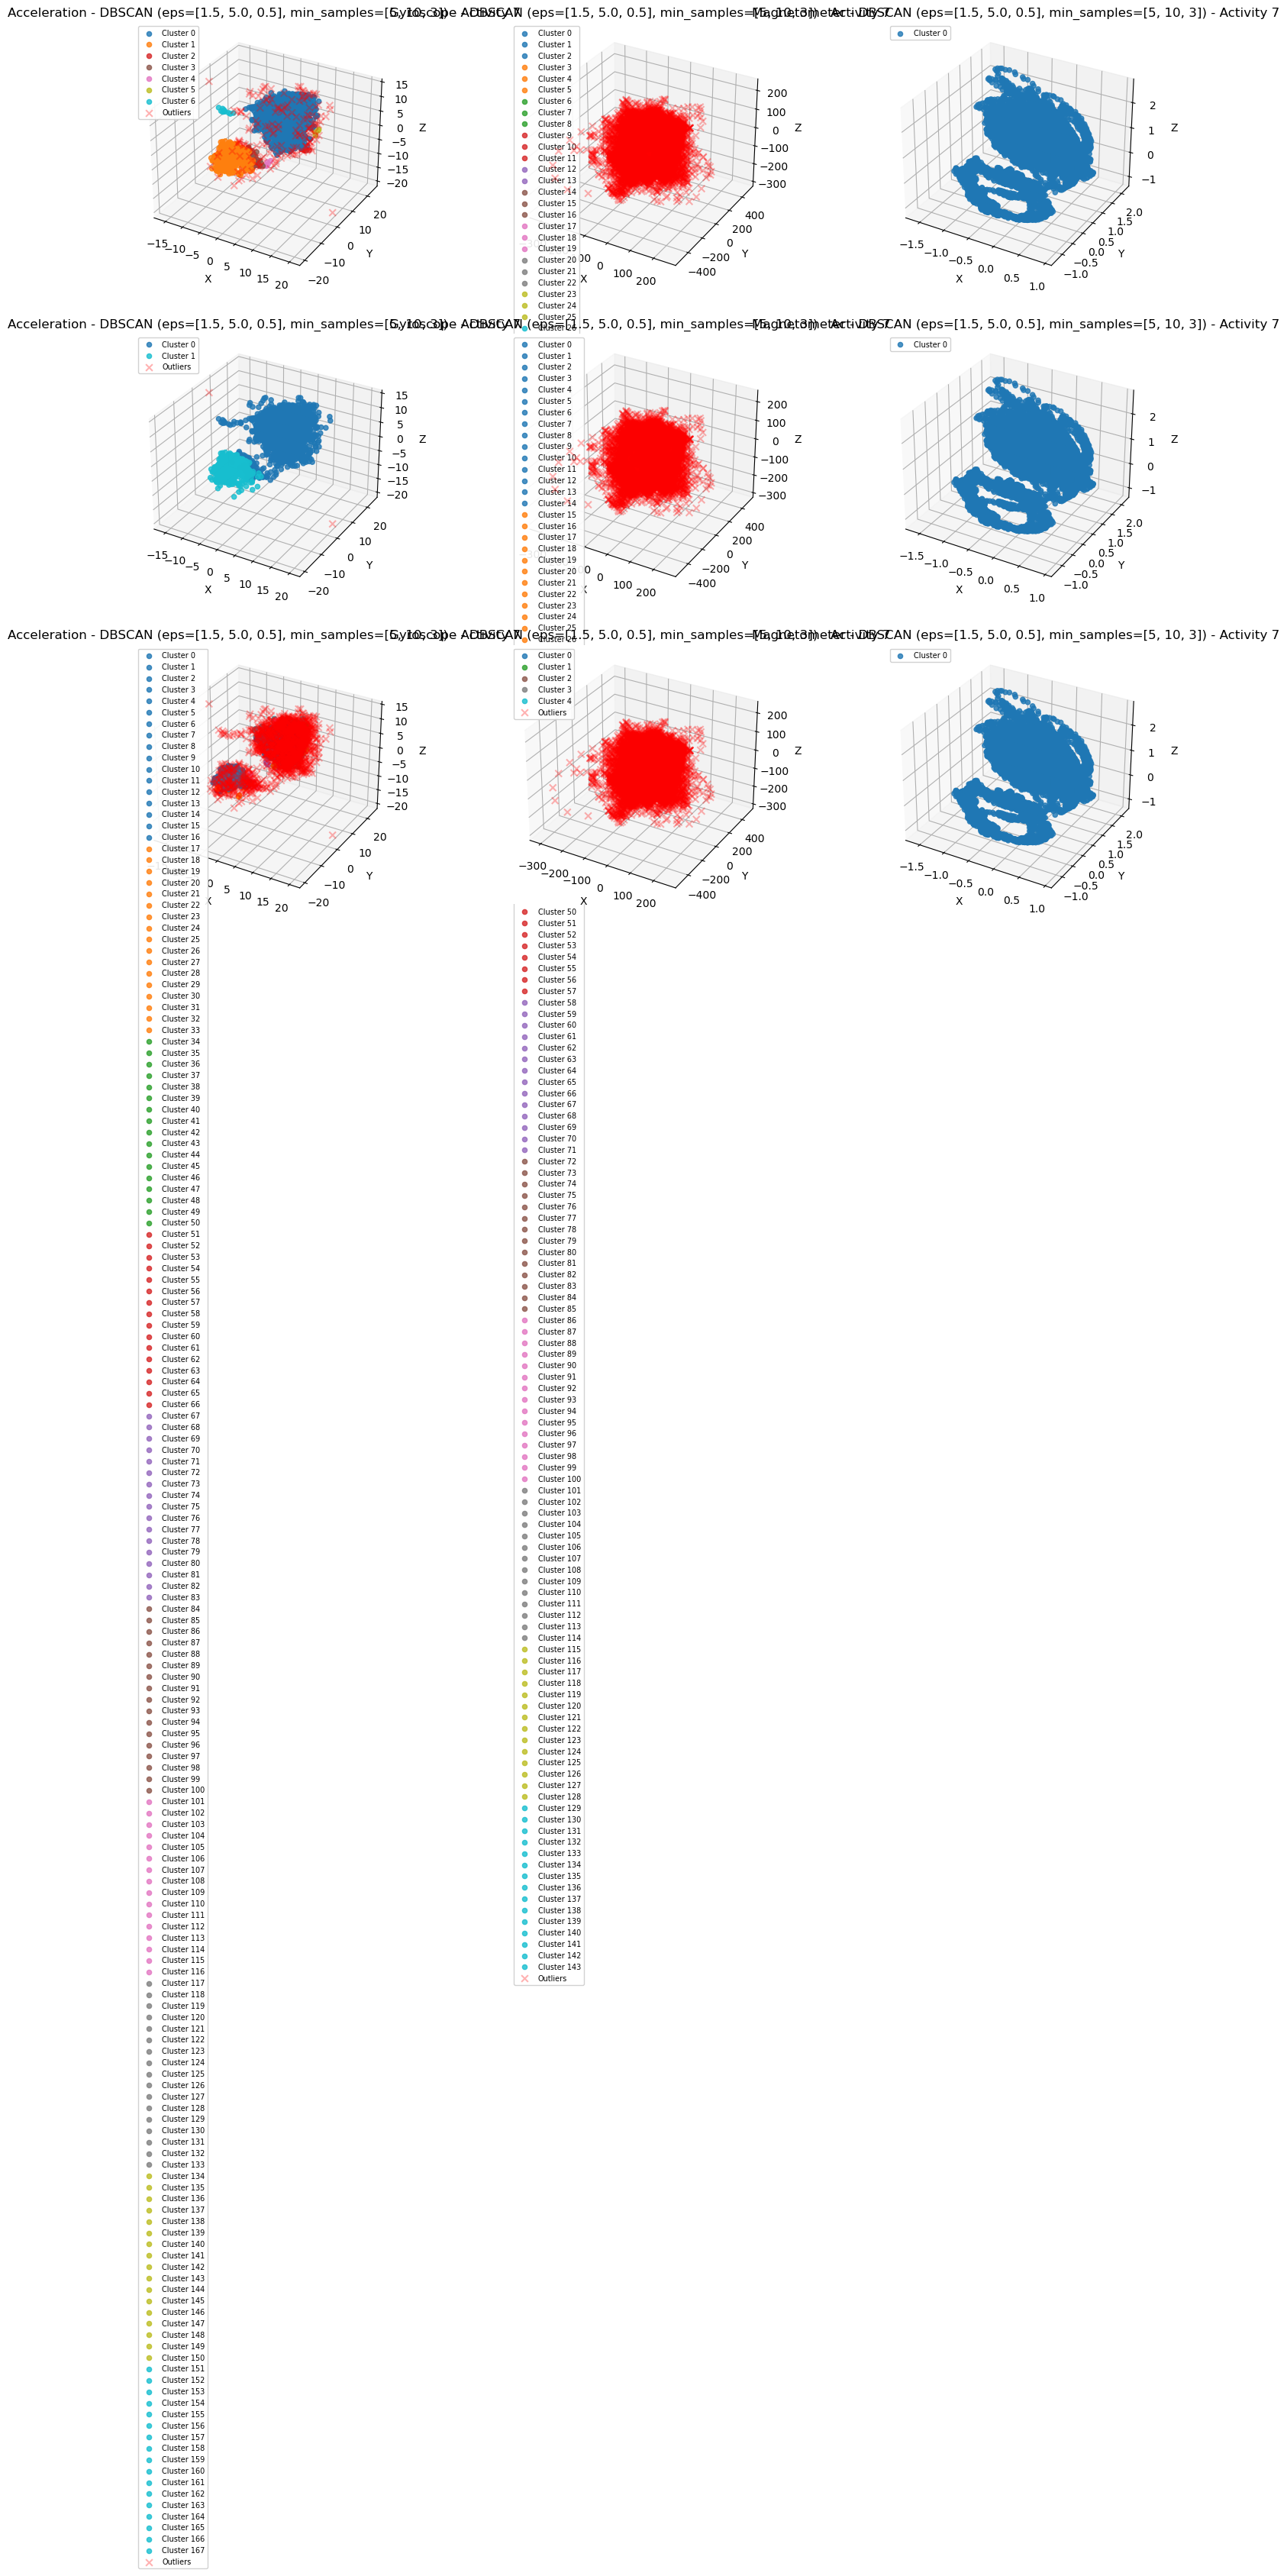

In [ ]:
from sklearn.cluster import DBSCAN

def dbscan_outliers_3d(data, eps, min_samples, device_id=2, activity_filter=None):
    sensors = [1, 2, 3]
    labels_map = {1: 'Acceleration', 2: 'Gyroscope', 3: 'Magnetometer'}
    cols_map = {1: (2, 3, 4), 2: (5, 6, 7), 3: (8, 9, 10)}
    
    n_cols = 3
    n_rows = len(eps)

    fig = plt.figure(figsize=(6 * n_cols , 5 * n_rows))
    for row_idx, (eps_value, min_samples_value) in enumerate(zip(eps, min_samples)):
        for col_idx, sensor in enumerate(sensors):
            ax = fig.add_subplot(n_rows, n_cols, row_idx * n_cols + col_idx + 1, projection='3d')
            label = labels_map[sensor]
            c = cols_map[sensor]

            # Filtrar device e atividade
            device_data = data[data[:, 1] == device_id]
            if activity_filter is not None:
                device_data = device_data[device_data[:, 12] == activity_filter]
            sensor_data = device_data[:, c]

            if (sensor_data.shape[0] == 0):
                ax.set_title(f"{label} - No data available")
                continue
            db = DBSCAN(eps=eps_value, min_samples=min_samples_value)
            labels = db.fit_predict(sensor_data)

            # Outliers
            outliers_index = np.where(labels == -1)[0]
            unique_cluster_labels = set(labels) - {-1}
            n_clusters = len(unique_cluster_labels)
            n_noise = len(outliers_index)
            print("Encontrados %d clusters e %d outliers no %s" % (n_clusters, n_noise, label))

            title = f"{label} - DBSCAN (eps={eps}, min_samples={min_samples})"
            if activity_filter is not None:
                title += f" - Activity {int(activity_filter)}"
            ax.set_title(title)

            colors = cm.get_cmap('tab10', n_clusters)

            if n_clusters > 0:
                for cluster_id in unique_cluster_labels:
                    cluster_points_idx = np.where(labels == cluster_id)[0]
                    cluster_color = colors(cluster_id)

                    ax.scatter(sensor_data[cluster_points_idx, 0],
                               sensor_data[cluster_points_idx, 1],
                               sensor_data[cluster_points_idx, 2],
                               color=cluster_color, s=20, alpha=0.8,
                               label=f'Cluster {cluster_id}')
            if n_noise > 0:
                ax.scatter(sensor_data[outliers_index, 0],
                           sensor_data[outliers_index, 1],
                           sensor_data[outliers_index, 2],
                           color='red', s=40, alpha=0.3, marker='x',
                           label='Outliers')
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')
            ax.legend(loc='upper left', fontsize=7, framealpha=0.9)
    plt.tight_layout()
    plt.show()

# Execução
eps_values = [1.5, 5.0, 0.5]
min_samples_values = [5, 10, 3]
dbscan_outliers_3d(data, eps=eps_values, min_samples=min_samples_values, device_id=2, activity_filter=7)

### Observações
Após utilizar o DBSCAN com os parametros eps=1.5 e min_samples=5, ficou clara a sensibilidade do algoritmo a estes parâmetros.
- Com estes parâmetros, o DBSCAN, não funciona bem para todos os sensores:
    - **Aceleração(7 clusters, 183 outliers)**: Foi o resultado mais razoável. O número de clusters encontrados pode refletir a atividade realizada e o número de outliers não é zero mas também não é excessivo.
    - **Giroscópio(29 clusters, 43638 outliers)**: O resultado não é satisfatório. O número de outliers é extremamente elevado, indicando que o eps é demasiado pequeno para a densidade dos dados. O número elevado de clusters também sugere que o eps é pequeno, fazendo com que pequenas densidades sejam consideradas clusters distintos. 
    - **Magnetómetro(1 cluster, 0 outliers)**: Este resultado pode indicar o oposto. Parâmetros demasiado grandes, que fizeram com que todos os pontos fossem agrupados num único cluster ou os dados são excecionalmente uniformes e sem pontos ruidosos.
### Ajuste dos Parâmetros
O próximo passo foi ajustar os parâmetros eps e min_samples para obtermos um resultado adequado para cada sensor. Após alguns testes, os seguintes parâmetros foram escolhidos:
- **Aceleração**: eps=1.5, min_samples=5
- **Giroscópio**: eps=5.0, min_samples=10
- **Magnetómetro**: eps=0.5, min_samples=3

## Exercício 4
Extração de informação característica: o objetivo será comprimir o espaço do problema,
extraindo informação característica discriminante que permita implementar soluções
eficazes do problema de classificação.

### Exercício 4.1
Usando as variáveis aplicadas na alínea 3.1, determine a significância
estatística dos seus valores médios nas diferentes atividades. Observe que
poderá aferir a normalidade da distribuição usando, por exemplo, o teste Kolmogorov-Smirnov (ver documentação do SciPy). Para rever a escolha de
testes estatísticos sugere-se a referência. Comente

In [ ]:
import numpy as np
from scipy.stats import kstest, shapiro, norm, f_oneway, kruskal

def module_significance(data, sensor, alpha=0.05):
    if sensor == 1:
        c = (2,3,4)
        label = 'Acceleration'
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 1, 2 ou 3")

    mod = np.sqrt((data[:, c]**2).sum(axis=1))
    activities = data[:, 12].astype(int)
    unique_activities = np.unique(activities)

    # Teste de normalidade
    all_normal = True
    for act in unique_activities:
        sample = mod[activities == act]
        mean_sample = np.mean(sample)
        std_sample = np.std(sample)

        # Kolmogorov–Smirnov
        stat_ks, p_ks = kstest(sample, 'norm', args=(mean_sample, std_sample))
        if p_ks <= alpha:
            all_normal = False

        # Shapiro–Wilk
        stat_sw, p_sw = shapiro(sample)
        if p_sw <= alpha:
            all_normal = False

    # Preparar amostras por atividade
    samples = [mod[activities == act] for act in unique_activities]

    # Escolher o teste estatístico
    if all_normal:
        stat_anova, p_value = f_oneway(*samples)
        test_name = "ANOVA (paramétrico)"
    else:
        stat_kruskal, p_value = kruskal(*samples)
        test_name = "Kruskal–Wallis (não-paramétrico)"

    # Mostrar resultado
    print(f"\n{label} — {test_name}")
    print(f"p-value = {p_value:.4e}")
    if p_value <= alpha:
        print("Rejeito H0")
    else:
        print("Aceito H0")


In [ ]:
module_significance(data, sensor=1) 
module_significance(data, sensor=2)
module_significance(data, sensor=3)

c:\Users\didia\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")



Acceleration — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0

Gyroscope — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0

Magnetometer — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0


### Observações
#### Geral:

- Foram analisados os módulos dos sensores para todas as atividades, comparando os valores médios entre elas
- Para decidir o teste apropriado, foi verificada a normalidade de cada atividade usando Kolmogorov–Smirnov e Shapiro–Wilk. Nenhuma das atividades apresentou distribuição normal, justificando o uso do teste não-paramétrico Kruskal–Wallis.
- Os p-values obtidos foram praticamente zero para todos os sensores, indicando que as diferenças observadas entre atividades não ocorrem por acaso.

##### Acceleration:
Teste de Significância:
- Kruskal–Wallis: p-value ≈ 0
- Decisão: Rejeita-se H₀.
##### Observação: 
Há diferenças estatisticamente significativas nos valores médios do módulo de aceleração entre as atividades. Atividades dinâmicas apresentam valores médios mais elevados que as estáticas, refletindo variações reais de movimento.

##### Gyroscope:
Teste de Significância:
- Kruskal–Wallis: p-value ≈ 0
- Decisão: Rejeita-se H₀.
##### Observação: 
Os valores médios do giroscópio diferem significativamente entre as atividades. Atividades sem movimento apresentam módulo próximo de zero, enquanto atividades com movimento apresentam valores mais elevados, captando claramente a rotação do corpo.

##### Magnetometer:
Teste de Significância:
- Kruskal–Wallis: p-value ≈ 0
- Decisão: Rejeita-se H₀.
##### Observação: 
As diferenças nos valores médios do magnetómetro também são estatisticamente significativas. Contudo, a distinção entre atividades não é tão nítida quanto nos outros sensores. É possível que outliers relacionados com interferências magnéticas (ex.: estruturas metálicas) influenciem os resultados.

#### Conclusão:
- Todos os sensores apresentam diferenças significativas entre as atividades, confirmando que os valores médios dos módulos dos sensores podem ser usados para diferenciar atividades humanas.
- O Kruskal–Wallis mostrou-se adequado devido à ausência de normalidade nos dados.
- Em termos práticos, aceleração e giroscópio são mais discriminativos entre atividades, enquanto o magnetómetro pode ser útil em situações específicas, como detectar ambientes com interferência magnética ou movimentos de escada.

### Exercício 4.2

Desenvolva as rotinas necessárias à extração do feature set temporal e 
espectral sugerido no artigo4. Para o efeito deverá: 
- Ler o artigo e identificar o conjunto de features temporais e espectrais 
identificadas por estes autores. 
- Considere apenas janelas temporais (sliding windows) de 5 segundos, 
com overlap de 50% para segmentar os dados para a extração de 
features. Se um segmento cobrir mais do que uma atividade, descarte 
esse segmento. Ver em particular a Figura 2 e Tabela 1 do artigo1. 
- Para cada feature deverá elaborar uma rotina para a respetiva extração.  
- Usando as rotinas elaboradas no item anterior, deverá escrever o código 
necessário para extrair o vetor de features em cada instante. 

1ºpasso: dividir os dados em janelas de 5 segundos com 50% de overlap

In [ ]:
def create_windows(data, window_length, overlap):
    windows = []
    step = window_length * (1 - overlap)
    
    # Encontrar onde mudam as pessoas OU dispositivos
    person_device_changes = np.where(
        (np.diff(data[:, 0]) != 0) |  # mudança pessoa
        (np.diff(data[:, 1]) != 0)    # mudança device
    )[0] + 1
    
    start = np.concatenate(([0], person_device_changes))
    end = np.concatenate((person_device_changes, [len(data)]))
    
    for i in range(len(start)):
        sub_data = data[start[i]:end[i]]
    
        timestamps = sub_data[:, 11]
        start_time = timestamps[0]
        end_time = timestamps[-1]
        
        # Só criar janelas se o aquelas linhas tiverem intervalo maior que a janela
        if end_time - start_time < window_length:
            continue
        
        # Criar todas as janelas de uma vez
        window_starts = np.arange(start_time, end_time - window_length + step, step)
        window_ends = window_starts + window_length
        
        start_indices = np.searchsorted(timestamps, window_starts)
        end_indices = np.searchsorted(timestamps, window_ends)
        
        for start_idx, end_idx in zip(start_indices, end_indices):
            if start_idx < end_idx:
                window_data = sub_data[start_idx:end_idx]
                labels = window_data[:, 12]
                
                # Ver se as atividades são todas iguais
                if labels[0] == labels[-1] and np.all(labels == labels[0]):
                    windows.append(window_data)
    
    return windows

In [ ]:
windows =create_windows(data, window_length=5.0, overlap=0.5)

## FEATURES TEMPORAIS

MEAN

MEDIAN

STD

VARIANCE

ROOT MEAN SQUARE

AVERAGE DERIVATES

SKEWNESS

KURTOSIS

IQR

ZERO CROSSING RATE

MEAN CROSSING RATE

PAIRWISE CORRELATION

MOVEMENT INTENSITY

SIGNAL MAGNITUDE AREA

EIGENVALUES OF DOMINANT DIRECTIONS

CORRELATIONS ACCELERATION GRAVITY VS HEADING

AVERAGED VELOCITY GRAVITY

AVERAGED ROTATION ANGLES GRAVITY

## FEATURES ESPECTRAIS

SPECTRAL ENTROPY

DOMINANT FREQUENCY

AVERAGED ACCELERATION ENERGY

AVERAGED ROTATION ENERGY

### Exercício 4.3
Desenvolva o código necessário para implementar o PCA de um feature set;
poderá usar implementações existentes.

#### Explicação da rotina implementada:
A função tem como objetivo preparar a análise de Componentes Principais (PCA) e recebe como parametro um feature_set que já vem normalizado. A rotina segue os seguintes passos:
1. Cálcula o número máximo de componentes que podem ser extraídas, que é limitado pelo menor valor entre o número de amostras e o número de features originais.
2. É criado um objeto PCA da biblioteca sklearn com o número máximo de componentes.
3. O PCA é então executado sobre o feature_set. Durante este passo, o algoritmo identifica as direções de máxima variância nos dados e calcula quanta da variância total é explicada por cada componente principal.
4. A função retorna o objeto PCA treinado, que contém as componentes principais e a variância explicada por cada uma.

In [ ]:
from sklearn.decomposition import PCA
def implement_PCA(feature_set):
    X_input = feature_set
    print(f"Entry data. Shape: {X_input.shape}")
    n_samples, n_features = X_input.shape
    max_components = min(n_samples, n_features)

    print(f"Training PCA with {max_components} components")
    pca = PCA(n_components=max_components)
    # Train object with normalized data
    pca.fit(X_input)
    return pca

### Exercício 4.4
Determine a importância de cada vetor principal na explicação da
variabilidade do espaço de features. Note que deverá normalizar as features
usando o z-score. Quantas dimensões deverá usar para explicar 75% do
feature set?

#### Explicação da rotina implementada:
Após obter o objeto PCA treinado procedemos à analise para determinar a importância de cada componente principal e quantas são necessárias para satisfazer o critério de 75% da variância explicada:
1. O `explained_variance_ratio_` do PCA é um vetor de números. O primeiro elemento é a percentagem de variância que a Componente Principal 1 explica, o segundo número é a percentagem que a Componente Principal 2 explica, e assim sucessivamente. Os valores são também ordenados do mais importante para o menos importante.
2. É calculada a quantidade de componentes principais calculadas. (`cumulative_variance`)
3. Depois então, é calculada a soma cumulativa da variância. Isto é utilizado para determinar quantas componentes são necessárias para explicar 75% da variância total. (`np.any(cumulative_variance >= 0.75)`)
4. O valor exato da variância cumulativa é obtido utilizando o número de componentes que foram determinadas (`n_components_needed`)

In [ ]:
def analyse_pca(pca_object, threshold=0.75):
    explained_variance_ratio = pca_object.explained_variance_ratio_
    n_total_components = len(explained_variance_ratio)
    cumulative_variance = np.cumsum(explained_variance_ratio)

    if np.any(cumulative_variance >= threshold):
        n_components_needed = np.argmax(cumulative_variance >= threshold) + 1
        variance_explained_by_need = cumulative_variance[n_components_needed-1]
        print(f"Para explicar pelo menos {threshold * 100}% da variância, são necessários: {n_components_needed} components")
        print(f"     (Com {n_components_needed} componentes, a variância explicada acumulada é de {variance_explained_by_need*100:.2f}%)")
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, n_total_components + 1), cumulative_variance, marker='o', linestyle='--')
        plt.title('Variância Cumulativa Explicada pelo PCA')
        plt.xlabel('Número de Componentes Principais')
        plt.ylabel('Variância Cumulativa Explicada')
        plt.axhline(y=threshold, color='r', linestyle=':', label=f'{threshold*100}% Threshold')
        plt.axvline(x=n_components_needed, color='g', linestyle=':', label=f'{n_components_needed} Componentes')
        plt.ylim(0, 1.1)
        plt.xticks(range(1, n_total_components + 1))
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()
    return n_components_needed
# Falta aqui a variavel dos features_set
feature_set = ["Falta aqui os dados"]
trained_pca_object = implement_PCA(feature_set)
analyse_pca(trained_pca_object)


#### Exercício 4.4.1.
Indique como poderia obter as features relativas a esta compressão e exemplifique para um instante à sua escolha.

#### Exercicio 4.4.2.
Indique as vantagens e as limitações desta abordagem.

### Exercício 4.5
Desenvolva o código necessário para implementar o Fisher feature Score e o ReliefF. Poderá usar implementações existentes.

### Exercício 4.6.
Identifique as 10 melhores features de acordo com o Fisher Score e o ReliefF e compare os resultados.

### Exercício 4.6.1.
Indique como poderia obter as features relativas a esta compressão e exemplifique para um instante à sua escolha.

### Exercício 4.6.2.
Indique as vantagens e as limitações desta abordagem.